In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/migration_original.csv")

df.head()

,event-id,visible,timestamp,location-long,location-lat,manually-marked-outlier,visible.1,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,study-name,ECMWF Interim Full Daily Invariant Low Vegetation Cover,NCEP NARR SFC Vegetation at Surface,ECMWF Interim Full Daily Invariant High Vegetation Cover
0,1082620685,True,2009-05-27 14:00:00.000,24.58617,61.24783,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.039229,NaN,0.960771
1,1082620686,True,2009-05-27 20:00:00.000,24.58217,61.23267,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.040803,NaN,0.959197
2,1082620687,True,2009-05-28 05:00:00.000,24.53133,61.18833,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.052201,NaN,0.947799
3,1082620688,True,2009-05-28 08:00:00.000,24.58200,61.23283,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.040818,NaN,0.959182
4,1082620689,True,2009-05-28 14:00:00.000,24.58250,61.23267,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.040753,NaN,0.959247


In [2]:
df.shape

(89867, 15)

In [3]:
df.columns

Index(['event-id', 'visible', 'timestamp', 'location-long', 'location-lat',
       'manually-marked-outlier', 'visible.1', 'sensor-type',
       'individual-taxon-canonical-name', 'tag-local-identifier',
       'individual-local-identifier', 'study-name',
       'ECMWF Interim Full Daily Invariant Low Vegetation Cover',
       'NCEP NARR SFC Vegetation at Surface',
       'ECMWF Interim Full Daily Invariant High Vegetation Cover'],
      dtype='str')

In [4]:
df = df.rename(columns={
    'timestamp': 'time',
    'location-long': 'lon',
    'location-lat': 'lat',
    'individual-local-identifier': 'animal_id',
    'ECMWF Interim Full Daily Invariant Low Vegetation Cover': 'veg_low',
    'ECMWF Interim Full Daily Invariant High Vegetation Cover': 'veg_high'
})

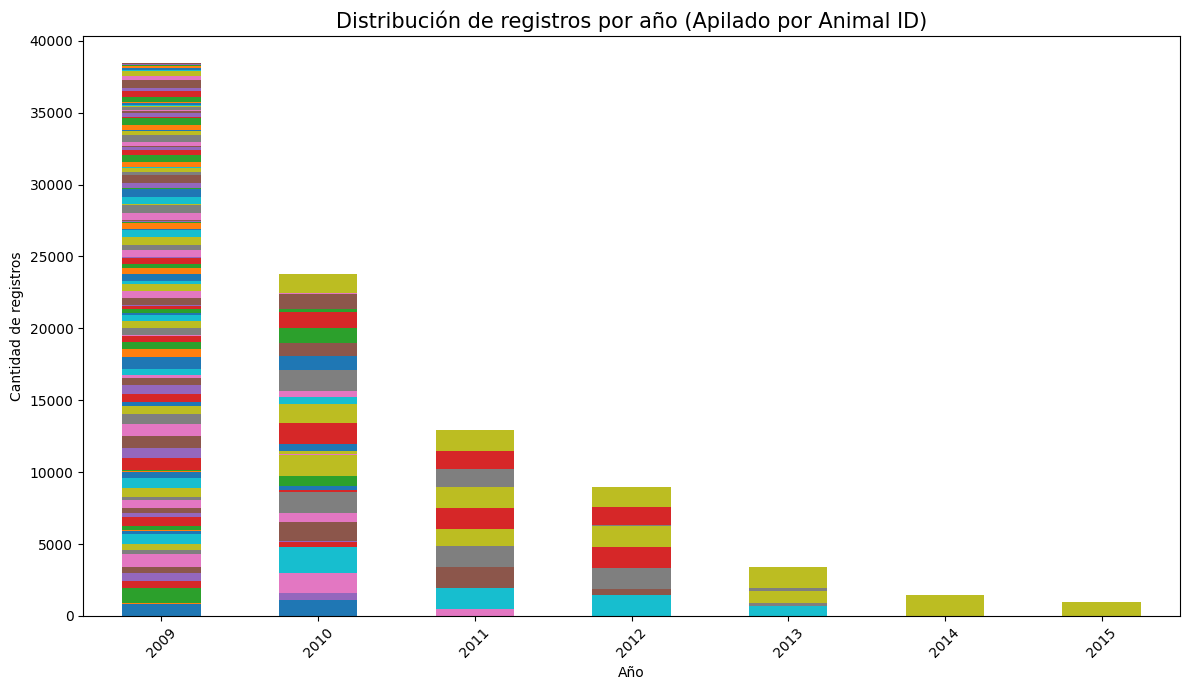

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Asegurar que 'time' sea datetime y crear la columna 'year'
# Esto es lo que falta en tu celda actual para que el groupby no falle
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year

# 2. Crear la tabla de frecuencias (Año vs Animal)
# Ahora 'year' y 'animal_id' existen con seguridad
pivot_df = df.groupby(['year', 'animal_id']).size().unstack(fill_value=0)

# 3. Graficar de forma apilada
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 7), legend=False)

# Configuración visual
plt.title('Distribución de registros por año (Apilado por Animal ID)', fontsize=15)
plt.xlabel('Año')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45) # Rotar años para mejor lectura

# 4. Cálculo de pérdida (como pediste antes)
# Suponiendo que df_final es tu versión filtrada y df es la original:
if 'df_final' in locals():
    n_antes = len(df)
    n_despues = len(df_final)
    perdidos = n_antes - n_despues
    porcentaje = (perdidos / n_antes) * 100 if n_antes > 0 else 0
    
    print(f"Registros iniciales: {n_antes}")
    print(f"Registros eliminados: {perdidos}")
    print(f"Porcentaje de datos perdidos: {porcentaje:.2f}%")

plt.tight_layout()
plt.show()

Cantidad exacta de registros por hora:
hour
0       530
3        25
4      4579
5     15466
6      2104
7      4624
8     15591
9      2098
10       22
12       27
13     4601
14    15656
15     2118
16       20
18       24
19     4614
20    15613
21     2134
22       21


✅ Imagen guardada en: /home/jllorens/Desktop/TFG/version2/notebooks/img/distribucion_horas.png


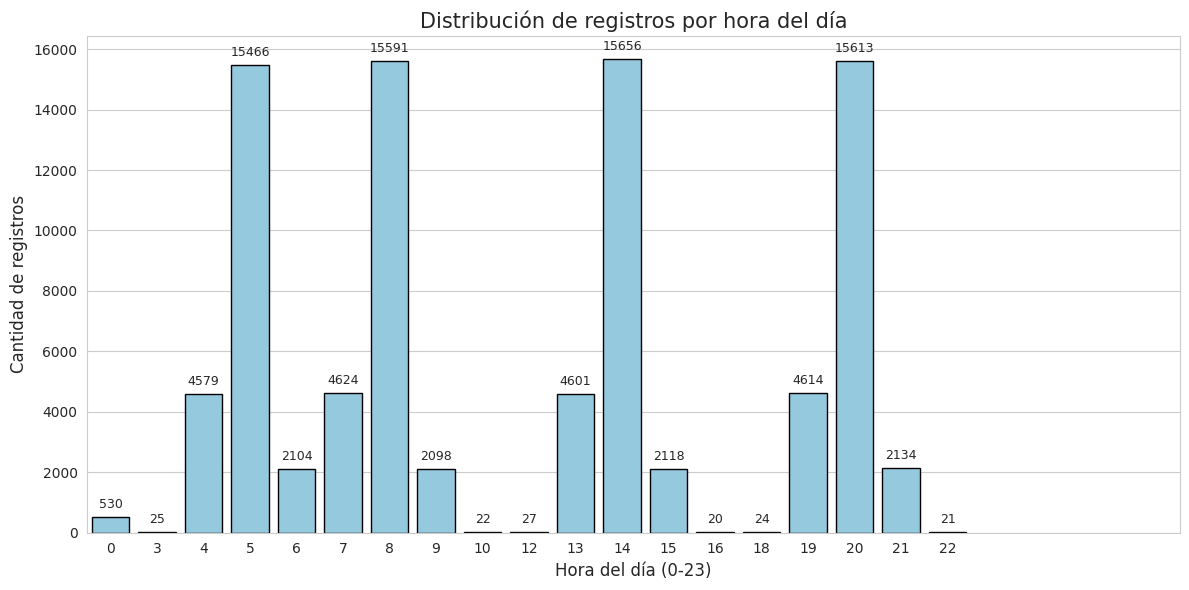

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Asegurar que 'time' sea datetime y extraer la hora
df['hour'] = pd.to_datetime(df['time']).dt.hour

# --- PARTE 1: CÁLCULO DE DATOS EXACTOS ---
conteo_horas = df['hour'].value_counts().sort_index()
print("Cantidad exacta de registros por hora:")
print(conteo_horas.to_string())

# --- PARTE 2: GRÁFICO ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Graficamos
ax = sns.countplot(data=df, x='hour', color='skyblue', edgecolor='black')

# Añadir los números encima de las barras para mayor claridad visual
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.title('Distribución de registros por hora del día', fontsize=15)
plt.xlabel('Hora del día (0-23)', fontsize=12)
plt.ylabel('Cantidad de registros', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()

# --- PARTE 3: GUARDADO SEGURO Y VISUALIZACIÓN ---
try:
    # Intenta detectar la ruta del script (funciona en archivos .py)
    ruta_base = Path(__file__).resolve().parent
    carpeta_img = ruta_base.parent / "img"
except NameError:
    # Si falla (Jupyter/Consola), usa el directorio actual
    carpeta_img = Path.cwd() / "img"

# Crear la carpeta si no existe
carpeta_img.mkdir(parents=True, exist_ok=True)
ruta_archivo = carpeta_img / "distribucion_horas.png"

# CRÍTICO: Guardar ANTES de show() para evitar imagen en blanco
plt.savefig(str(ruta_archivo), dpi=300, bbox_inches='tight')
print(f"✅ Imagen guardada en: {ruta_archivo}")

# Finalmente, mostrar en pantalla
plt.show()

In [7]:
# 1. Obtener el conteo por hora y asegurar que estén todas las horas (0-23)
conteo_horas = df['hour'].value_counts().reindex(range(24), fill_value=0).sort_index()

# 2. Identificar las 4 horas con más registros
# nlargest(4) nos da los valores más altos
top_4_horas = conteo_horas.nlargest(4)

print("--- Análisis de Picos y sus Horas Adyacentes ---")

# 3. Iterar sobre los 4 máximos para calcular la suma con sus vecinos
for hora, cantidad in top_4_horas.items():
    # Definimos los vecinos (con % 24 para que la hora 0 conecte con la 23 si fuera necesario)
    hora_previa = (hora - 1) % 24
    hora_siguiente = (hora + 1) % 24
    
    cant_previa = conteo_horas[hora_previa]
    cant_siguiente = conteo_horas[hora_siguiente]
    
    suma_total = cantidad + cant_previa + cant_siguiente
    
    print(f"\nPico en la Hora {hora:02d}:00")
    print(f"  - Cantidad en hora pico: {cantidad}")
    print(f"  - Vecinos: Hora {hora_previa:02d} ({cant_previa}) y Hora {hora_siguiente:02d} ({cant_siguiente})")
    print(f"  - SUMA TOTAL (ventana de 3h): {suma_total}")

--- Análisis de Picos y sus Horas Adyacentes ---

Pico en la Hora 14:00
  - Cantidad en hora pico: 15656
  - Vecinos: Hora 13 (4601) y Hora 15 (2118)
  - SUMA TOTAL (ventana de 3h): 22375

Pico en la Hora 20:00
  - Cantidad en hora pico: 15613
  - Vecinos: Hora 19 (4614) y Hora 21 (2134)
  - SUMA TOTAL (ventana de 3h): 22361

Pico en la Hora 08:00
  - Cantidad en hora pico: 15591
  - Vecinos: Hora 07 (4624) y Hora 09 (2098)
  - SUMA TOTAL (ventana de 3h): 22313

Pico en la Hora 05:00
  - Cantidad en hora pico: 15466
  - Vecinos: Hora 04 (4579) y Hora 06 (2104)
  - SUMA TOTAL (ventana de 3h): 22149


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 89867 entries, 0 to 89866
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   event-id                             89867 non-null  int64         
 1   visible                              89867 non-null  bool          
 2   time                                 89867 non-null  datetime64[us]
 3   lon                                  89867 non-null  float64       
 4   lat                                  89867 non-null  float64       
 5   manually-marked-outlier              0 non-null      float64       
 6   visible.1                            89867 non-null  bool          
 7   sensor-type                          89867 non-null  str           
 8   individual-taxon-canonical-name      89867 non-null  str           
 9   tag-local-identifier                 89867 non-null  int64         
 10  animal_id            

In [9]:
df.shape

(89867, 17)

In [10]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['animal_id', 'time']).reset_index(drop=True)

df.head()

,event-id,visible,time,lon,lat,manually-marked-outlier,visible.1,sensor-type,individual-taxon-canonical-name,tag-local-identifier,animal_id,study-name,veg_low,NCEP NARR SFC Vegetation at Surface,veg_high,year,hour
0,1082620685,True,2009-05-27 14:00:00,24.58617,61.24783,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.039229,NaN,0.960771,2009,14
1,1082620686,True,2009-05-27 20:00:00,24.58217,61.23267,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.040803,NaN,0.959197,2009,20
2,1082620687,True,2009-05-28 05:00:00,24.53133,61.18833,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.052201,NaN,0.947799,2009,5
3,1082620688,True,2009-05-28 08:00:00,24.58200,61.23283,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.040818,NaN,0.959182,2009,8
4,1082620689,True,2009-05-28 14:00:00,24.58250,61.23267,NaN,True,gps,Larus fuscus,91732,91732A,Navigation experiments in lesser black-backed ...,0.040753,NaN,0.959247,2009,14


In [11]:
print("Número de aves:", df['animal_id'].nunique())

Número de aves: 126


In [12]:
df['animal_id'].value_counts().sort_index()

animal_id
91732A    1970
91733A      44
91734A    1060
91735A     477
91737A    1039
          ... 
91920A     172
91921A      49
91924A      25
91929A      37
91930A      47
Name: count, Length: 126, dtype: int64

In [13]:
print("Primera fecha:", df['time'].min())

Primera fecha: 2009-05-25 00:05:00


In [14]:
print("Última fecha:", df['time'].max())

Última fecha: 2015-08-27 09:00:00


In [15]:
n_gps = (df['sensor-type'].str.upper() == 'GPS').sum()
n_no_gps = (df['sensor-type'].str.upper() != 'GPS').sum()

print("Datos GPS:", n_gps)
print("Datos no GPS:", n_no_gps)

Datos GPS: 89867
Datos no GPS: 0


In [16]:
df['manually-marked-outlier'].unique()

array([nan])

In [17]:
df['manually-marked-outlier'].value_counts(dropna=False)

manually-marked-outlier
NaN    89867
Name: count, dtype: int64

In [18]:
df['visible.1'].unique()

array([ True])

In [19]:
(df['visible'] == df['visible.1']).all()

np.True_

In [20]:
df['visible.1'].unique()

array([ True])

In [21]:
df['visible.1'].value_counts(dropna=False)

visible.1
True    89867
Name: count, dtype: int64

In [22]:
df['NCEP NARR SFC Vegetation at Surface'].unique()

array([nan])

In [23]:
total = len(df)
validos = df['NCEP NARR SFC Vegetation at Surface'].notnull().sum()

print(f"Valores válidos: {validos}")
print(f"Porcentaje válido: {validos/total*100:.2f}%")

Valores válidos: 0
Porcentaje válido: 0.00%


In [24]:
df = df[[
    'animal_id',
    'time',
    'lon',
    'lat',
    'veg_low',
    'veg_high'
]]

In [25]:
df.groupby([df['animal_id'], df['time'].dt.date]).size()

animal_id  time      
91732A     2009-05-27    2
           2009-05-28    4
           2009-05-29    4
           2009-05-30    2
           2009-05-31    2
                        ..
91930A     2009-08-27    4
           2009-08-28    4
           2009-08-29    4
           2009-08-30    2
           2009-08-31    1
Length: 23585, dtype: int64

In [26]:
# Asegurar formato datetime
df['time'] = pd.to_datetime(df['time'])

# Extraer la hora
df['hora'] = df['time'].dt.hour

# Contar horas específicas
horas_objetivo = [5, 8, 14, 20]

conteo = df[df['hora'].isin(horas_objetivo)]['hora'].value_counts().sort_index()

conteo

hora
5     15466
8     15591
14    15656
20    15613
Name: count, dtype: int64

In [27]:
df['time'].dt.hour.value_counts().sort_index()

time
0       530
3        25
4      4579
5     15466
6      2104
7      4624
8     15591
9      2098
10       22
12       27
13     4601
14    15656
15     2118
16       20
18       24
19     4614
20    15613
21     2134
22       21
Name: count, dtype: int64

In [28]:
"""import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Aseguramos que el tiempo esté en formato datetime y extraemos solo la fecha
df['time'] = pd.to_datetime(df['time'])
df['fecha'] = df['time'].dt.date

# --- OPCIÓN A: Todas las aves en un solo gráfico (Recomendado para visión global) ---
plt.figure(figsize=(12, 6))
# Usamos un stripplot donde cada punto es un registro GPS
sns.stripplot(data=df, x='fecha', y='animal_id', jitter=False, marker="|", size=10, color="teal")

plt.title('Continuidad de Registros GPS por Ave', fontsize=14)
plt.xlabel('Fecha del Registro', fontsize=12)
plt.ylabel('ID del Ave', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- OPCIÓN B: Una gráfica individual por cada ave ---
unique_animals = df['animal_id'].unique()

for animal in unique_animals:
    subset = df[df['animal_id'] == animal]
    
    # Creamos un rango completo de fechas desde la primera a la última de ESA ave
    all_days = pd.date_range(start=subset['fecha'].min(), end=subset['fecha'].max())
    
    plt.figure(figsize=(12, 2))
    # Dibujamos una línea base gris que representa el periodo total
    plt.hlines(y=1, xmin=subset['fecha'].min(), xmax=subset['fecha'].max(), colors='lightgray', linewidth=1)
    
    # Pintamos los días con datos
    plt.plot(subset['fecha'], [1]*len(subset), 'o', color='royalblue', markersize=5, label='Día con GPS')
    
    plt.title(f'Línea de tiempo: Ave {animal}', loc='left', fontsize=12)
    plt.yticks([]) # Quitamos el eje Y porque no aporta info
    plt.xlabel('Fecha')
    plt.grid(axis='x', alpha=0.3)
    
    # Ajustamos el límite X para que todas las gráficas individuales se vean en contexto
    # (puedes quitar esto si prefieres que cada una se ajuste a su propio rango)
    # plt.xlim(df['fecha'].min(), df['fecha'].max()) 
    
    plt.tight_layout()
    plt.show()"""

'import matplotlib.pyplot as plt\nimport pandas as pd\nimport seaborn as sns\n\n# 1. Aseguramos que el tiempo esté en formato datetime y extraemos solo la fecha\ndf[\'time\'] = pd.to_datetime(df[\'time\'])\ndf[\'fecha\'] = df[\'time\'].dt.date\n\n# --- OPCIÓN A: Todas las aves en un solo gráfico (Recomendado para visión global) ---\nplt.figure(figsize=(12, 6))\n# Usamos un stripplot donde cada punto es un registro GPS\nsns.stripplot(data=df, x=\'fecha\', y=\'animal_id\', jitter=False, marker="|", size=10, color="teal")\n\nplt.title(\'Continuidad de Registros GPS por Ave\', fontsize=14)\nplt.xlabel(\'Fecha del Registro\', fontsize=12)\nplt.ylabel(\'ID del Ave\', fontsize=12)\nplt.xticks(rotation=45)\nplt.grid(axis=\'x\', linestyle=\'--\', alpha=0.6)\nplt.tight_layout()\nplt.show()\n\n# --- OPCIÓN B: Una gráfica individual por cada ave ---\nunique_animals = df[\'animal_id\'].unique()\n\nfor animal in unique_animals:\n    subset = df[df[\'animal_id\'] == animal]\n\n    # Creamos un rango 

In [29]:
import pandas as pd

# 1. Asegurar formato datetime y crear columna auxiliar de fecha y hora objetivo
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

# 2. Definir la hora objetivo (14:00) para cada registro
# Creamos una columna temporal con las 14:00 de ese mismo día
df['target_time'] = pd.to_datetime(df['date'].astype(str) + ' 14:00:00')

# 3. Calcular la diferencia absoluta en segundos respecto a las 14:00
df['diff_seconds'] = (df['time'] - df['target_time']).abs().dt.total_seconds()

# 4. Quedarnos con el registro que tenga la diferencia mínima por cada animal y cada día
df_14h = df.sort_values('diff_seconds').groupby(['animal_id', 'date']).first().reset_index()

# 5. Limpieza: Ordenar cronológicamente y eliminar columnas auxiliares
df_14h = df_14h.sort_values(['animal_id', 'time']).drop(columns=['target_time', 'diff_seconds'])

# Verificamos el resultado
print(f"Registros originales: {len(df)}")
print(f"Registros filtrados (uno por día/animal): {len(df_14h)}")
print(df_14h[['animal_id', 'time']].head())

Registros originales: 89867
Registros filtrados (uno por día/animal): 23585
  animal_id                time
0    91732A 2009-05-27 14:00:00
1    91732A 2009-05-28 14:00:00
2    91732A 2009-05-29 14:00:00
3    91732A 2009-05-30 08:00:00
4    91732A 2009-05-31 14:00:00


Recuento de registros por hora:
hora_exacta
4        21
5        73
6        12
7        37
8       485
9       114
10        3
12       27
13     4601
14    15656
15     2118
16       20
19      104
20      301
21       13
Name: count, dtype: int64

Número de horas diferentes presentes: 15


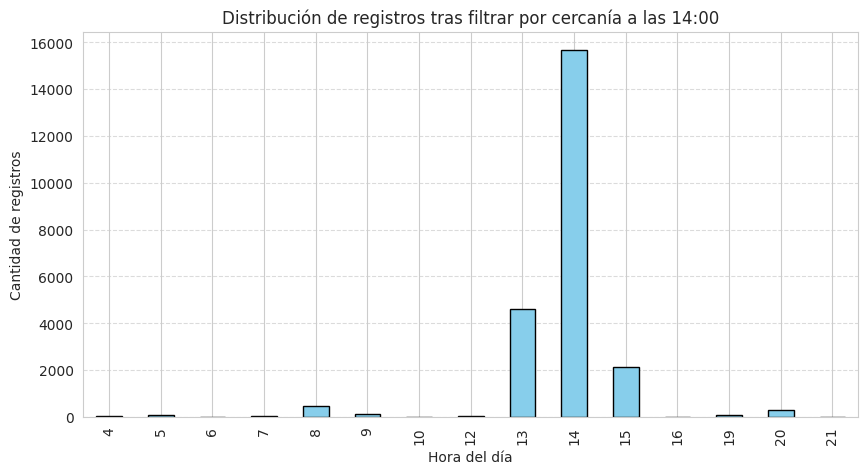

In [30]:
# 1. Extraemos solo la hora de los registros seleccionados
df_14h['hora_exacta'] = df_14h['time'].dt.hour

# 2. Contamos cuántas veces aparece cada hora
distribucion_horas = df_14h['hora_exacta'].value_counts().sort_index()

print("Recuento de registros por hora:")
print(distribucion_horas)

# 3. Calculamos cuántas horas distintas hay en total
print(f"\nNúmero de horas diferentes presentes: {df_14h['hora_exacta'].nunique()}")

# 4. (Opcional) Visualización rápida para tu memoria del TFG
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
distribucion_horas.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribución de registros tras filtrar por cercanía a las 14:00')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de registros')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [31]:
df_14h.shape

(23585, 9)

In [32]:
# Filtramos para quedarnos solo con el bloque central (Tolerancia de +/- 1 hora)
horas_validas = [13, 14, 15]
df_final = df_14h[df_14h['hora_exacta'].isin(horas_validas)].copy()

print(f"Registros después de eliminar horas atípicas: {len(df_final)}")
print(f"Porcentaje de datos conservados: {round(len(df_final)/len(df_14h)*100, 2)}%")

Registros después de eliminar horas atípicas: 22375
Porcentaje de datos conservados: 94.87%


In [33]:
df_final.columns

Index(['animal_id', 'date', 'time', 'lon', 'lat', 'veg_low', 'veg_high',
       'hora', 'hora_exacta'],
      dtype='str')

In [34]:
df_final.shape

(22375, 9)

In [35]:
# 1. Eliminar las columnas que sobran
df_final = df_final.drop(columns=[ 'time' ,'hora_exacta'])

# 2. Reordenar para que date y hora estén al principio junto al animal_id
# Obtenemos la lista de todas las columnas actuales
cols = df_final.columns.tolist()

# Creamos el nuevo orden: animal_id, date, hora y luego el resto
new_order = ['animal_id', 'date', 'hora'] + [c for c in cols if c not in ['animal_id', 'date', 'hora']]

df_final = df_final[new_order]

# Visualizamos el resultado
print(df_final.head())

  animal_id        date  hora       lon       lat   veg_low  veg_high
0    91732A  2009-05-27    14  24.58617  61.24783  0.039229  0.960771
1    91732A  2009-05-28    14  24.58250  61.23267  0.040753  0.959247
2    91732A  2009-05-29    14  24.58650  61.24750  0.039201  0.960799
4    91732A  2009-05-31    14  24.58700  61.24750  0.039128  0.960872
6    91732A  2009-06-02    14  24.49183  61.21700  0.056058  0.943942


In [36]:
import pandas as pd

# 1. Aseguramos que 'date' sea formato datetime para poder restar
df_final['date'] = pd.to_datetime(df_final['date'])
df_final = df_final.sort_values(['animal_id', 'date'])

# 2. Calculamos la diferencia de días entre un registro y el anterior por animal
df_final['dias_diff'] = df_final.groupby('animal_id')['date'].diff().dt.days

# 3. Identificamos dónde hay un salto (diferencia > 1 día o primer registro del animal)
# Creamos una marca cada vez que se rompe la secuencia de días seguidos
df_final['nueva_secuencia'] = (df_final['dias_diff'] > 1) | (df_final['dias_diff'].isna())

# 4. Creamos un ID único para cada segmento de días consecutivos
# El cumsum() irá sumando 1 cada vez que encuentre una 'nueva_secuencia'
df_final['segmento_id'] = df_final.groupby('animal_id')['nueva_secuencia'].cumsum()

# 5. Creamos una clave única real combinando animal y segmento
df_final['trayectoria_id'] = df_final['animal_id'].astype(str) + "_Seg" + df_final['segmento_id'].astype(str)

# Limpiamos columnas auxiliares
df_final = df_final.drop(columns=['dias_diff', 'nueva_secuencia', 'segmento_id'])

# Verificamos cuántos segmentos han salido y de qué longitud
stats_segmentos = df_final.groupby('trayectoria_id').size()
print(f"Número total de segmentos seguidos: {len(stats_segmentos)}")
print(f"Longitud media de los segmentos: {stats_segmentos.mean():.2f} días")

Número total de segmentos seguidos: 663
Longitud media de los segmentos: 33.75 días


In [37]:
# 1. Guardamos la cantidad de registros ANTES del filtro
n_registros_antes = len(df_final)

# Quedarse solo con secuencias de al menos 4 días seguidos
segmentos_validos = stats_segmentos[stats_segmentos >= 4].index
df_final = df_final[df_final['trayectoria_id'].isin(segmentos_validos)]

# 2. Guardamos la cantidad de registros DESPUÉS del filtro
n_registros_despues = len(df_final)

# 3. Calculamos la pérdida
datos_perdidos = n_registros_antes - n_registros_despues
porcentaje_perdido = (datos_perdidos / n_registros_antes) * 100

# Verificamos cuántos segmentos han salido y de qué longitud
stats_segmentos = df_final.groupby('trayectoria_id').size()

print(f"Número total de segmentos seguidos: {len(stats_segmentos)}")
print(f"Longitud media de los segmentos: {stats_segmentos.mean():.2f} días")
print(f"---")
print(f"Registros eliminados por el filtro: {datos_perdidos}")
print(f"Porcentaje de datos perdidos: {porcentaje_perdido:.2f}%")

Número total de segmentos seguidos: 480
Longitud media de los segmentos: 45.92 días
---
Registros eliminados por el filtro: 334
Porcentaje de datos perdidos: 1.49%


In [38]:
df_final.shape

(22041, 8)

In [39]:
import os

# 1. Definir la ruta del directorio y el nombre del archivo
output_dir = '../data/processed'
file_name = 'aves_procesado_markov.csv'
full_path = os.path.join(output_dir, file_name)

# 2. Crear la carpeta si no existe
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Carpeta creada en: {output_dir}")

# 3. Guardar el DataFrame
# index=False evita que se guarde una columna extra con los números de fila
df_final.to_csv(full_path, index=False)

print(f"¡Éxito! El dataset se ha guardado en: {full_path}")
print(f"Total de registros exportados: {len(df_final)}")

¡Éxito! El dataset se ha guardado en: ../data/processed/aves_procesado_markov.csv
Total de registros exportados: 22041


In [40]:
df_final.head()

,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id
6,91732A,2009-06-02,14,24.49183,61.21700,0.056058,0.943942,91732A_Seg3
7,91732A,2009-06-03,14,24.58617,61.24783,0.039229,0.960771,91732A_Seg3
8,91732A,2009-06-04,14,24.58583,61.24783,0.039279,0.960721,91732A_Seg3
9,91732A,2009-06-05,14,24.51350,61.23467,0.051076,0.948924,91732A_Seg3
10,91732A,2009-06-06,14,24.53950,61.24717,0.046140,0.953860,91732A_Seg3


In [41]:
df_final[df_final['animal_id'] == '91743A']['trayectoria_id'].nunique()

5

In [42]:
df_final[df_final['animal_id'] == '91743A']['trayectoria_id'].unique()

<StringArray>
['91743A_Seg1', '91743A_Seg2', '91743A_Seg3', '91743A_Seg4', '91743A_Seg5']
Length: 5, dtype: str

In [43]:
df_final[df_final['animal_id'] == '91743A']['trayectoria_id'].value_counts()

trayectoria_id
91743A_Seg2    19
91743A_Seg3    17
91743A_Seg1    11
91743A_Seg4     5
91743A_Seg5     4
Name: count, dtype: int64

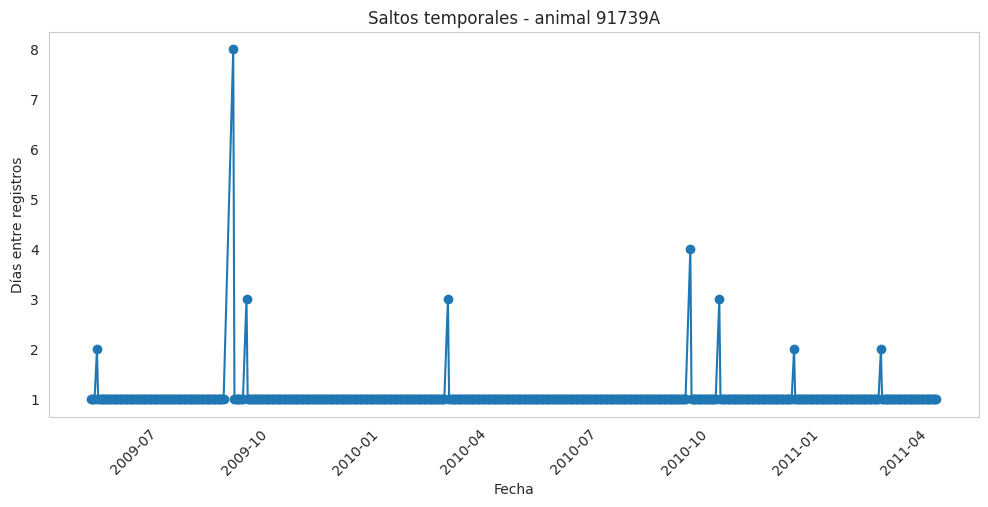

In [44]:
import matplotlib.pyplot as plt

# Filtrar animal
df_animal = df_final[df_final['animal_id'] == '91739A'].sort_values('date').copy()

# Calcular diferencia temporal entre registros (en días)
df_animal['delta_days'] = df_animal['date'].diff().dt.total_seconds() / (3600*24)

# Gráfica
plt.figure(figsize=(12,5))
plt.plot(df_animal['date'], df_animal['delta_days'], marker='o')

plt.xlabel("Fecha")
plt.ylabel("Días entre registros")
plt.title("Saltos temporales - animal 91739A")

plt.xticks(rotation=45)
plt.grid()

plt.show()

In [45]:
df_final.head()

,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id
6,91732A,2009-06-02,14,24.49183,61.21700,0.056058,0.943942,91732A_Seg3
7,91732A,2009-06-03,14,24.58617,61.24783,0.039229,0.960771,91732A_Seg3
8,91732A,2009-06-04,14,24.58583,61.24783,0.039279,0.960721,91732A_Seg3
9,91732A,2009-06-05,14,24.51350,61.23467,0.051076,0.948924,91732A_Seg3
10,91732A,2009-06-06,14,24.53950,61.24717,0.046140,0.953860,91732A_Seg3


In [46]:
# Filtramos usando los nombres de columna que me mostraste
df_animal = df_final.loc[
    df_final['animal_id'] == '91743A', 
    ['date', 'hora', 'lon', 'lat', 'veg_low', 'veg_high', 'trayectoria_id']
]

# Si quieres ordenar cronológicamente, usamos date y hora
df_animal = df_animal.sort_values(by=['date', 'hora'])

# Mostramos el resultado
print("Datos filtrados para el animal 91743A:")
print(df_animal.head())

Datos filtrados para el animal 91743A:
           date  hora       lon       lat   veg_low  veg_high trayectoria_id
2447 2009-05-26    14  22.98483  63.85967  0.002139  0.549774    91743A_Seg1
2448 2009-05-27    14  22.98483  63.85967  0.002139  0.549774    91743A_Seg1
2449 2009-05-28    14  22.98483  63.85967  0.002139  0.549774    91743A_Seg1
2450 2009-05-29    14  23.05317  63.81667  0.002604  0.669391    91743A_Seg1
2451 2009-05-30    14  23.66383  63.57317  0.010600  0.989400    91743A_Seg1


/tmp/ipykernel_27146/3286975514.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conteo_mensual_global.index, y=conteo_mensual_global.values, palette='viridis')


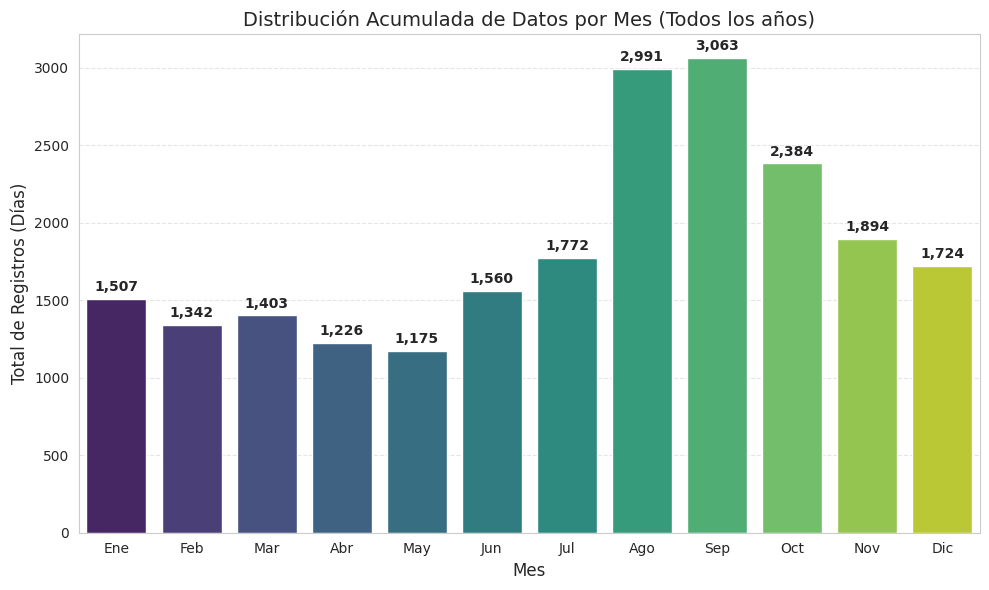

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer el número de mes (1-12) y el nombre del mes para que quede bonito
df_final['mes_num'] = df_final['date'].dt.month
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# 2. Contar registros por mes numérico
conteo_mensual_global = df_final['mes_num'].value_counts().sort_index()

# 3. Mapear los números a nombres para el eje X
conteo_mensual_global.index = [nombres_meses[i-1] for i in conteo_mensual_global.index]

# 4. Crear el gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=conteo_mensual_global.index, y=conteo_mensual_global.values, palette='viridis')

# Añadir los totales sobre las barras
for i, v in enumerate(conteo_mensual_global.values):
    ax.text(i, v + (max(conteo_mensual_global.values) * 0.01), f'{v:,}', 
            ha='center', va='bottom', fontweight='bold')

plt.title('Distribución Acumulada de Datos por Mes (Todos los años)', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total de Registros (Días)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_27146/778495504.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conteo_estaciones.index, y=conteo_estaciones.values, palette=colores, edgecolor='gray')


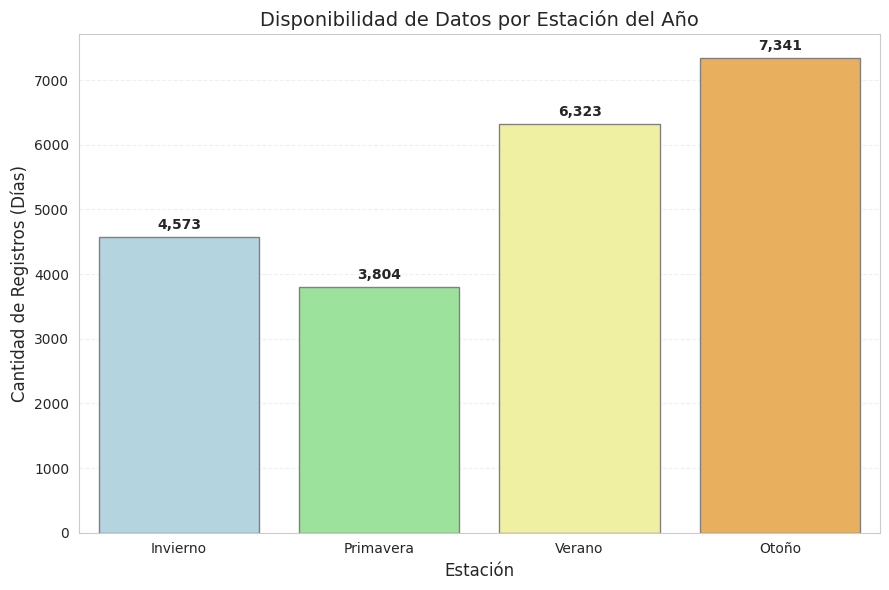

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Función para mapear meses a estaciones (Hemisferio Norte)
def asignar_estacion(mes):
    if mes in [12, 1, 2]:
        return 'Invierno'
    elif mes in [3, 4, 5]:
        return 'Primavera'
    elif mes in [6, 7, 8]:
        return 'Verano'
    else: # 9, 10, 11
        return 'Otoño'

# 2. Crear la columna de estación basándonos en el mes
# (Asumiendo que ya tienes 'mes_num' del paso anterior, si no: df_final['date'].dt.month)
df_final['estacion'] = df_final['date'].dt.month.apply(asignar_estacion)

# 3. Contar registros y asegurar el orden lógico de las estaciones
orden_estaciones = ['Invierno', 'Primavera', 'Verano', 'Otoño']
conteo_estaciones = df_final['estacion'].value_counts().reindex(orden_estaciones)

# 4. Gráfico de barras
plt.figure(figsize=(9, 6))
colores = ['#add8e6', '#90ee90', '#fdfd96', '#ffb347'] # Colores sugerentes: azul, verde, amarillo, naranja
ax = sns.barplot(x=conteo_estaciones.index, y=conteo_estaciones.values, palette=colores, edgecolor='gray')

# Etiquetas de datos
for i, v in enumerate(conteo_estaciones.values):
    ax.text(i, v + (max(conteo_estaciones.values) * 0.01), f'{v:,}', 
            ha='center', va='bottom', fontweight='bold')

plt.title('Disponibilidad de Datos por Estación del Año', fontsize=14)
plt.ylabel('Cantidad de Registros (Días)', fontsize=12)
plt.xlabel('Estación', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

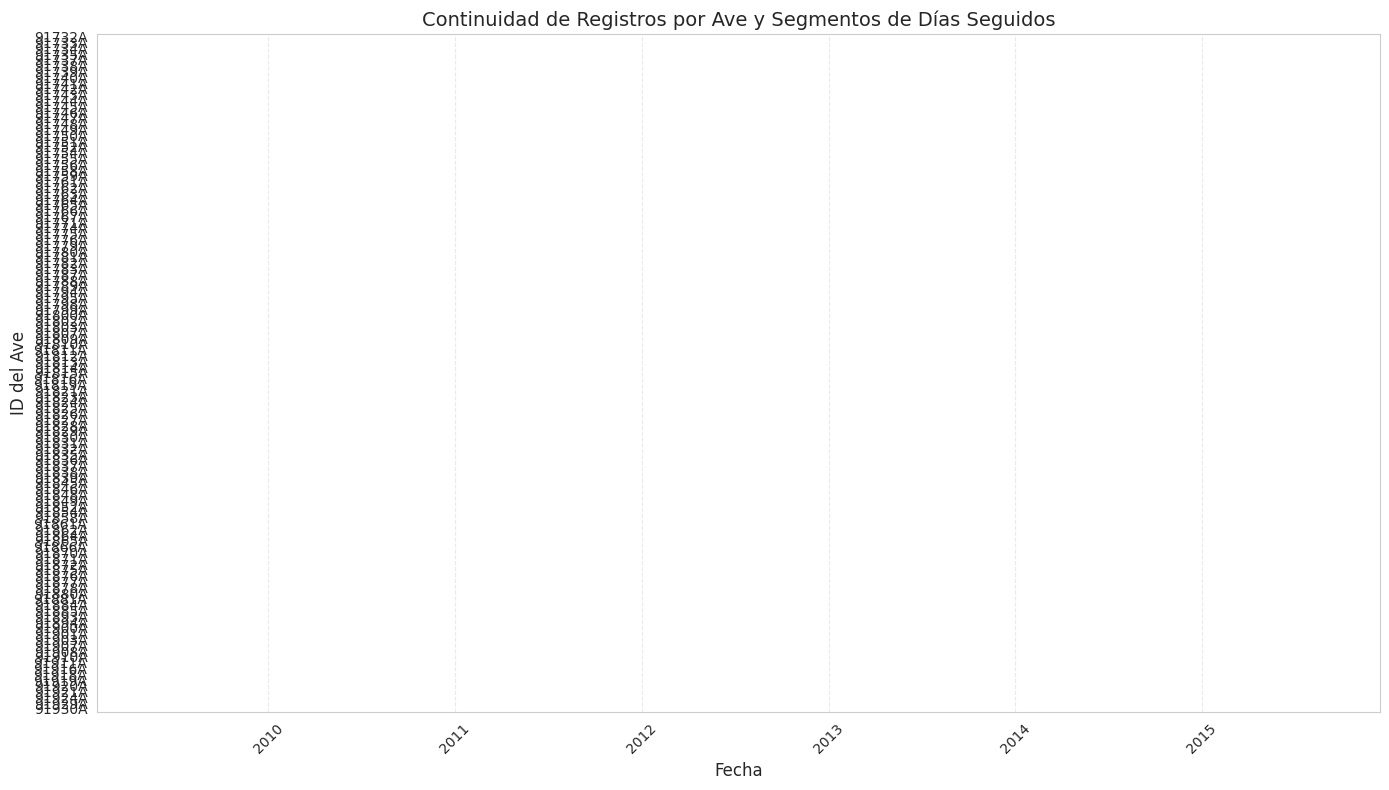

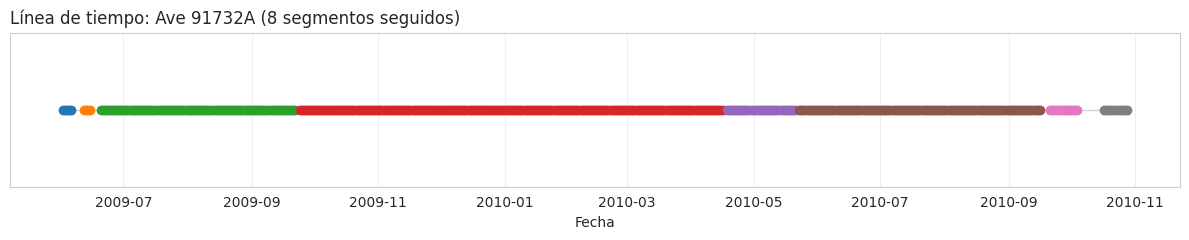

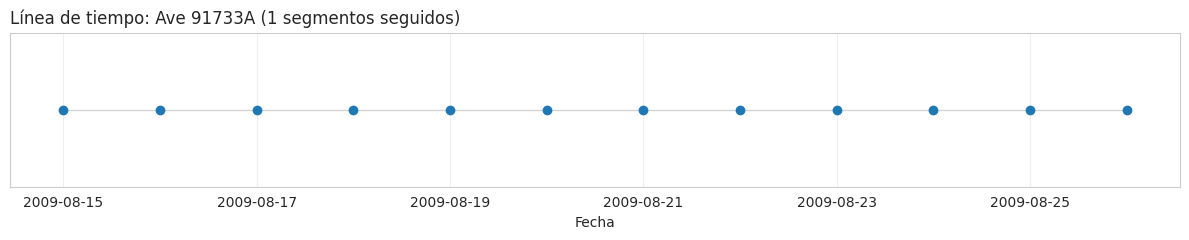

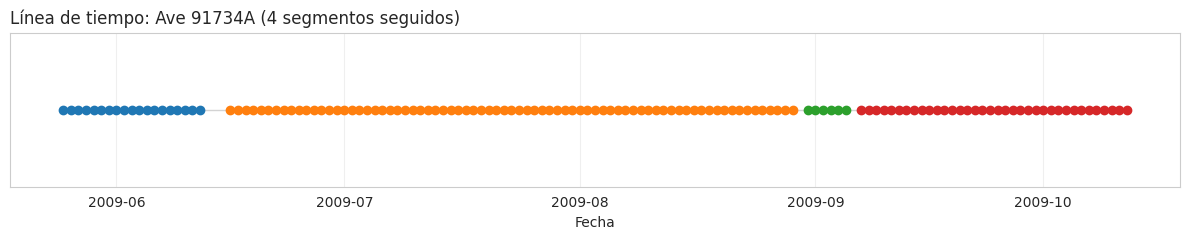

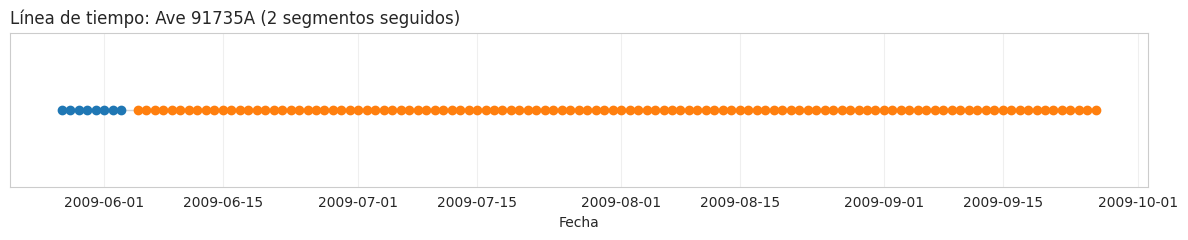

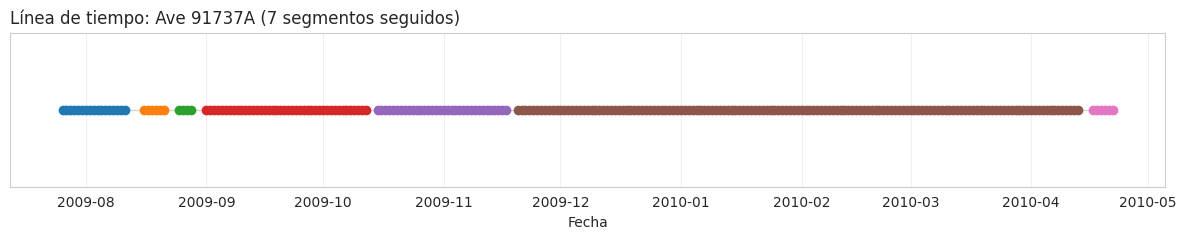

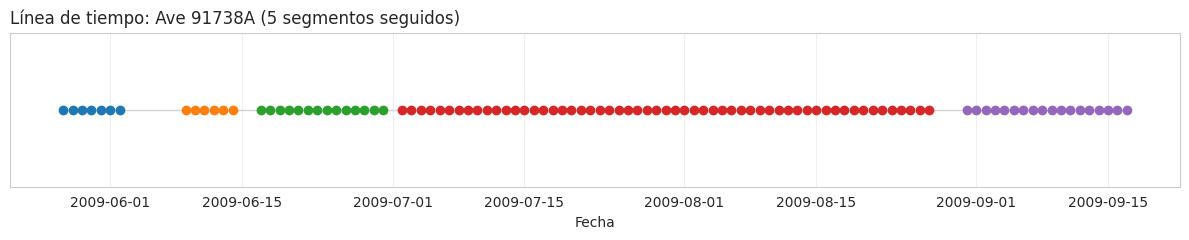

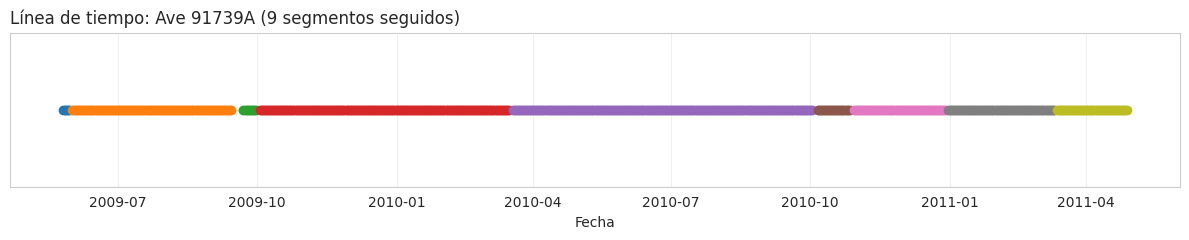

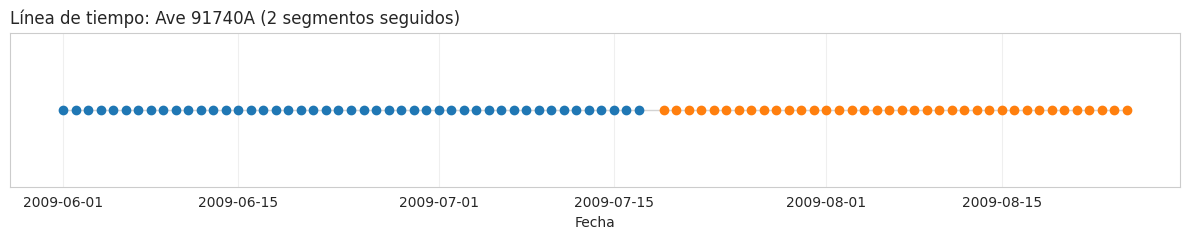

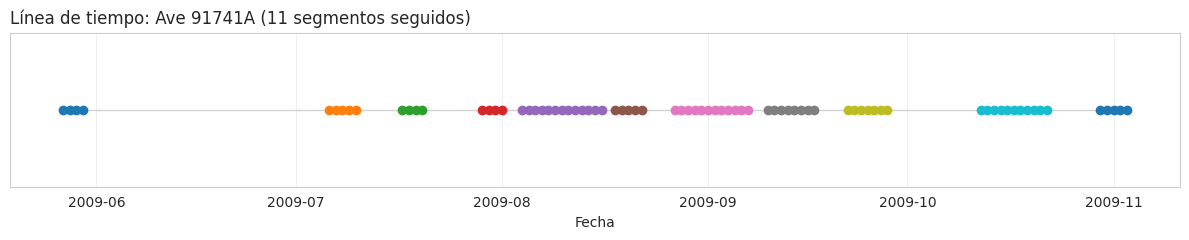

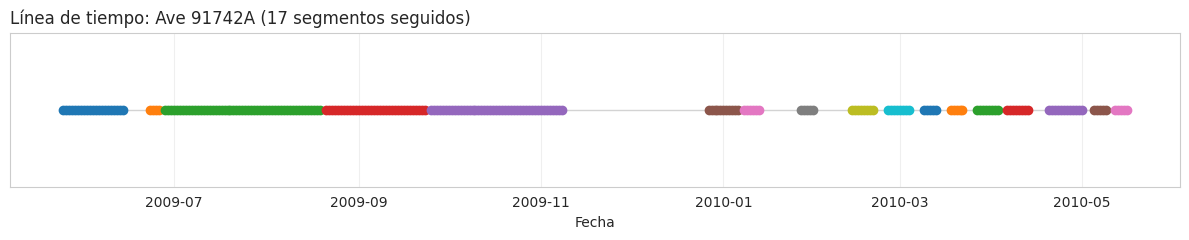

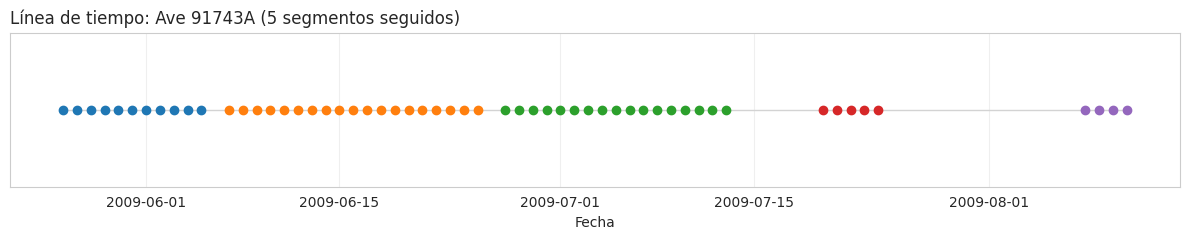

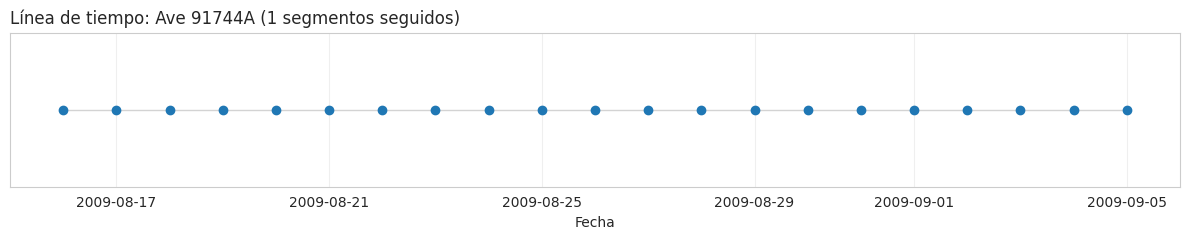

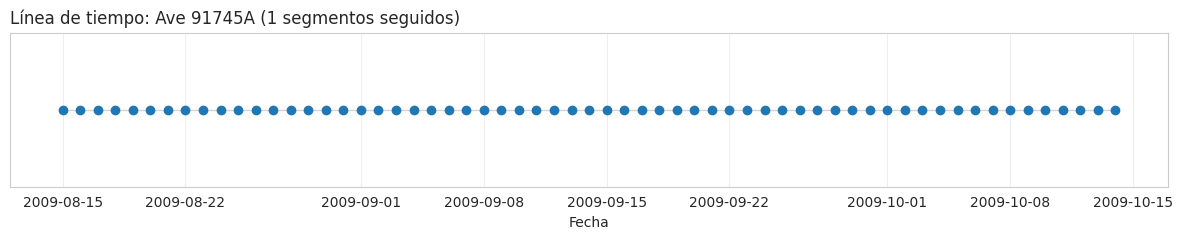

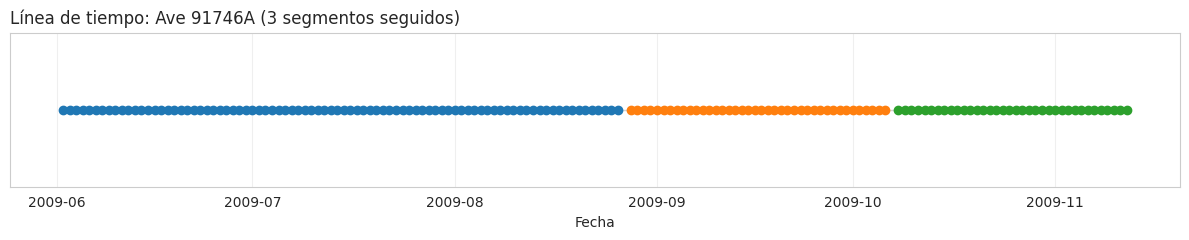

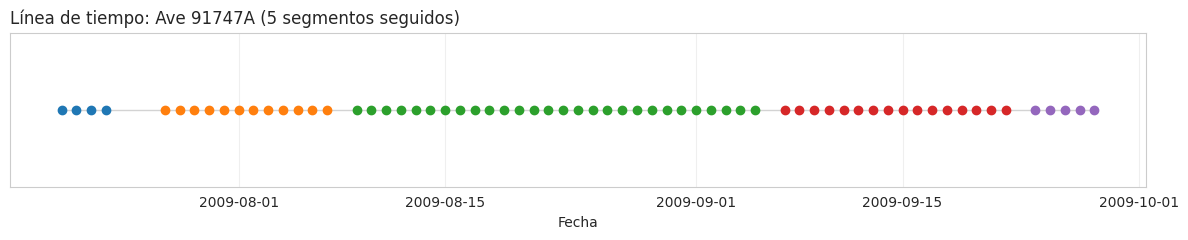

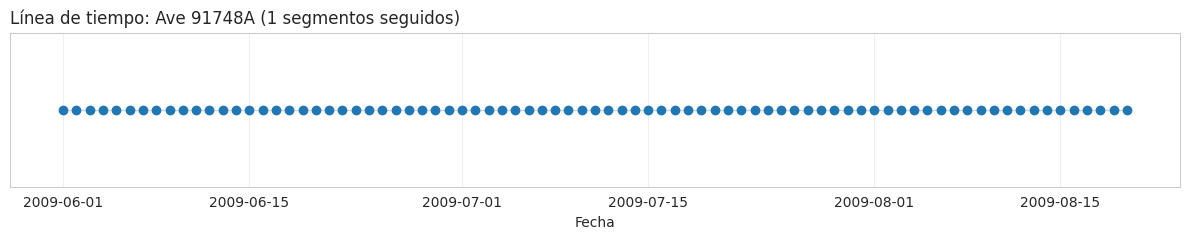

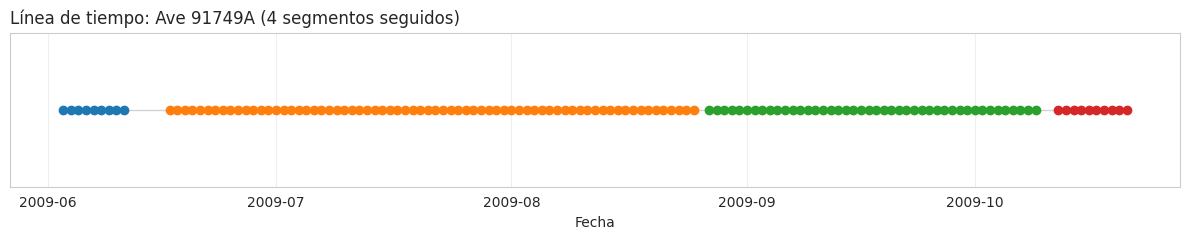

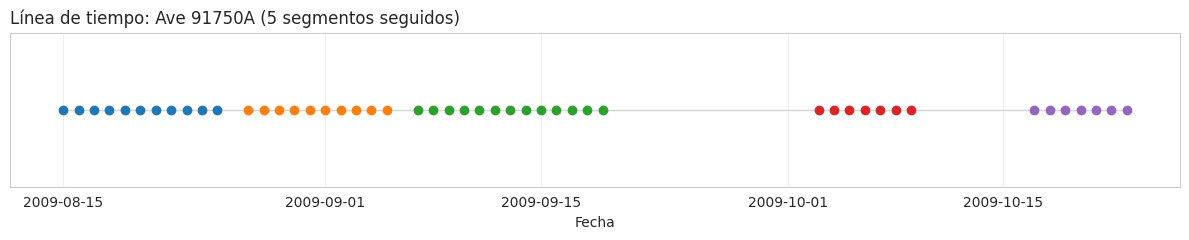

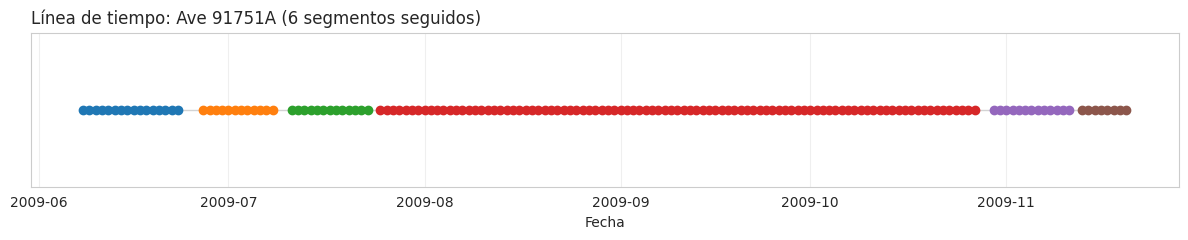

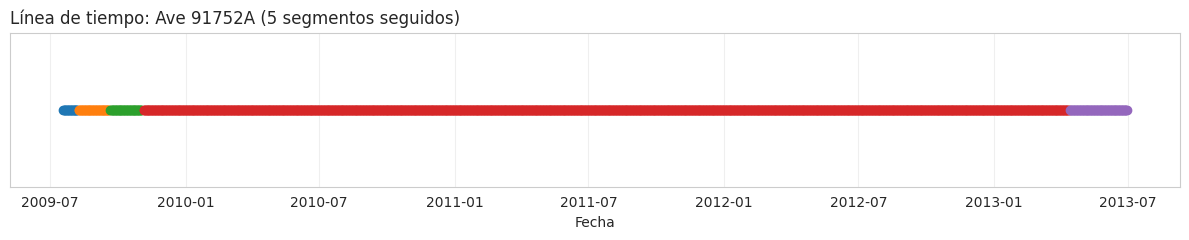

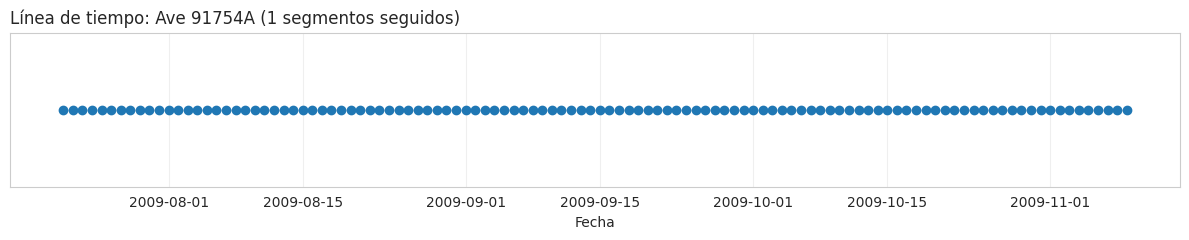

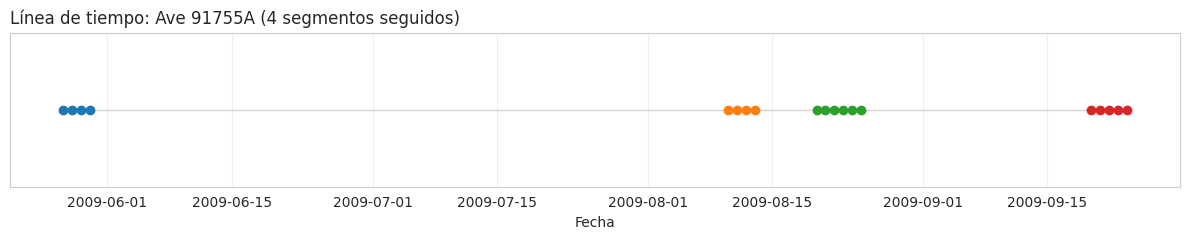

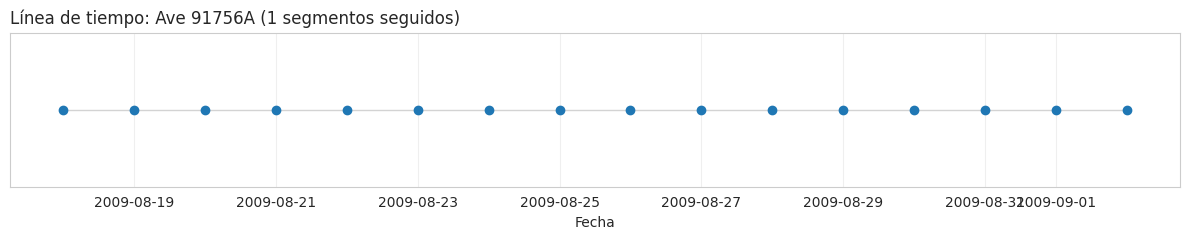

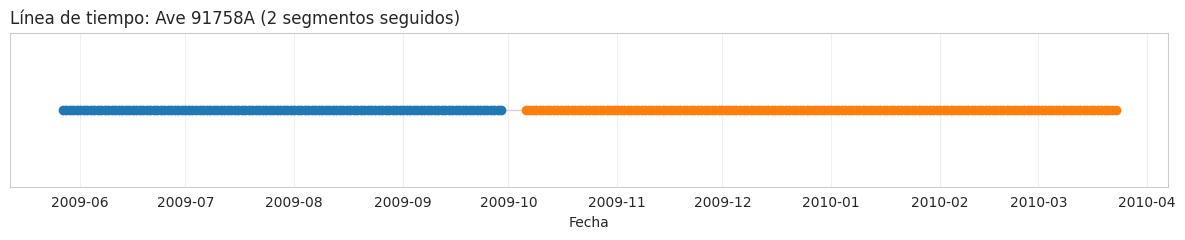

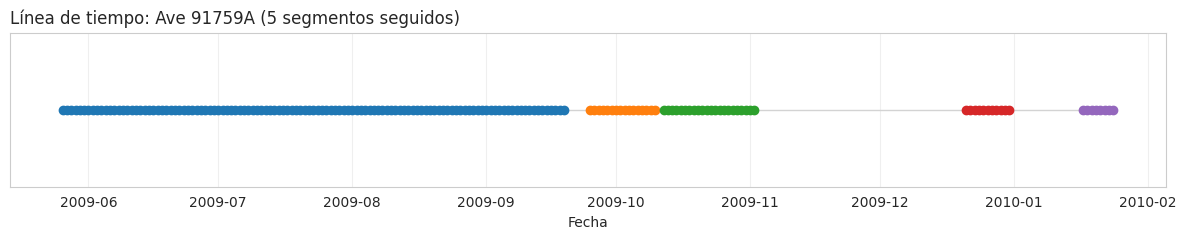

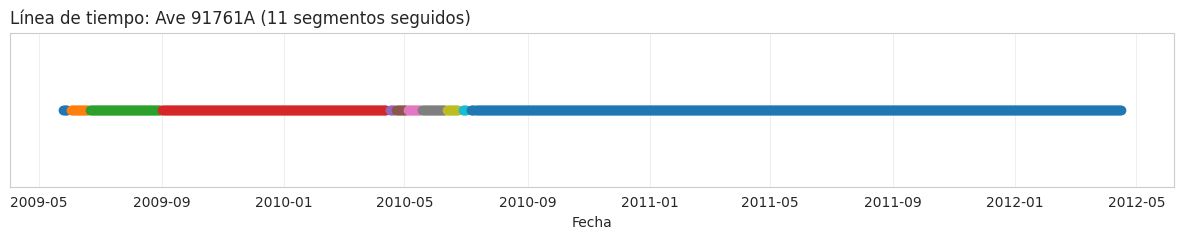

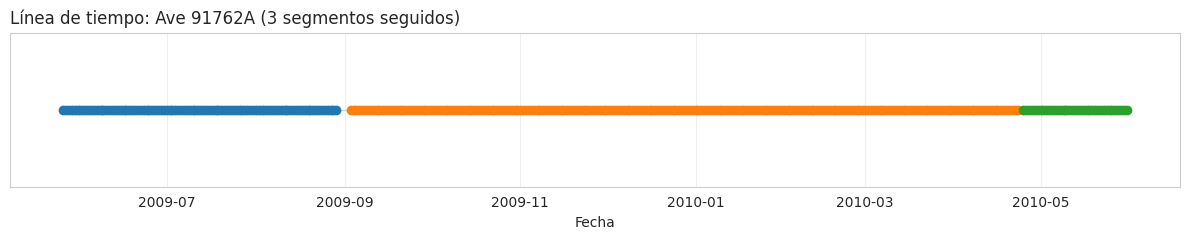

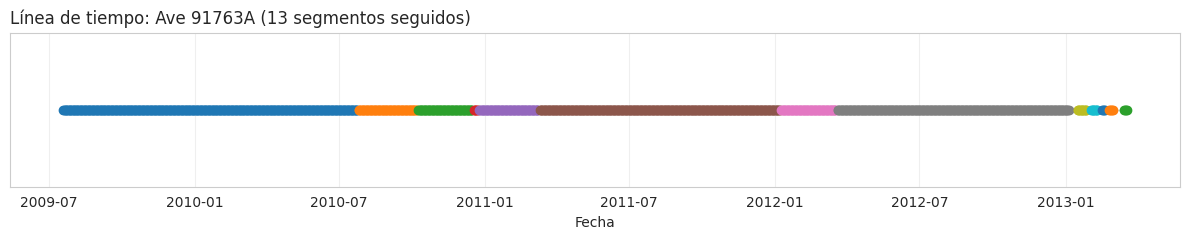

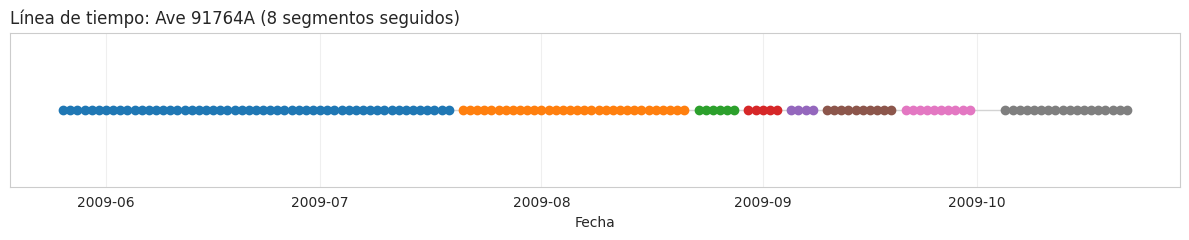

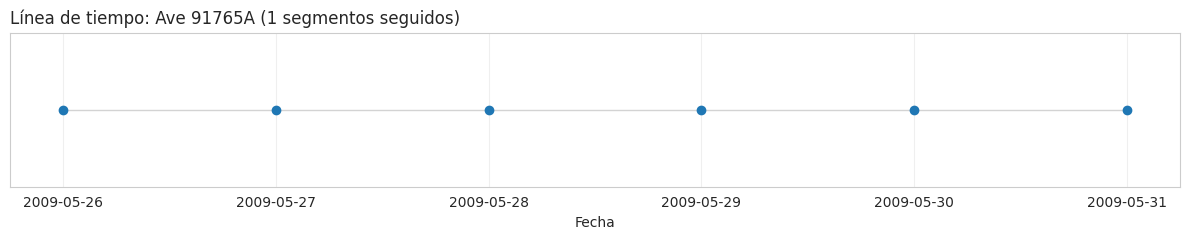

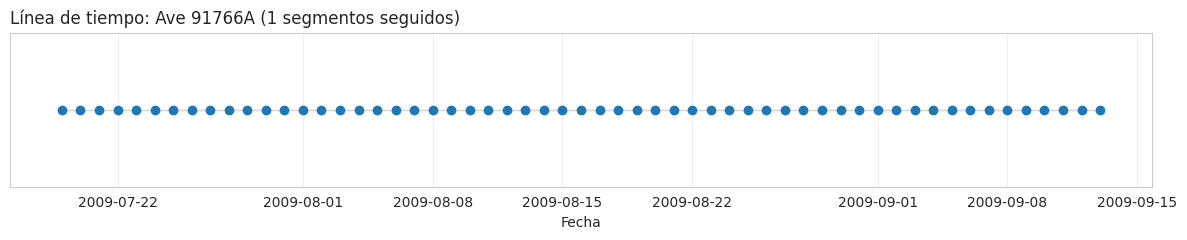

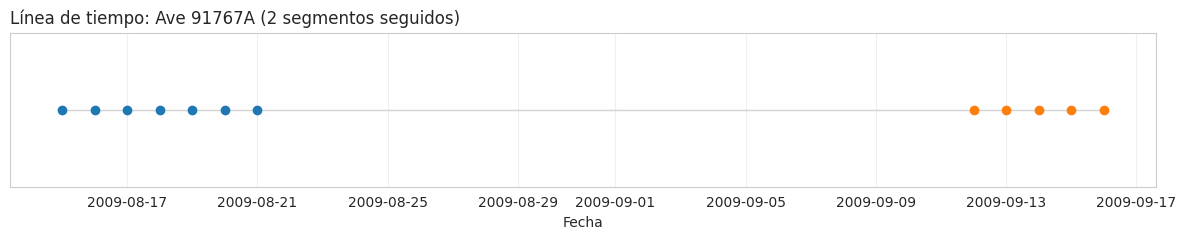

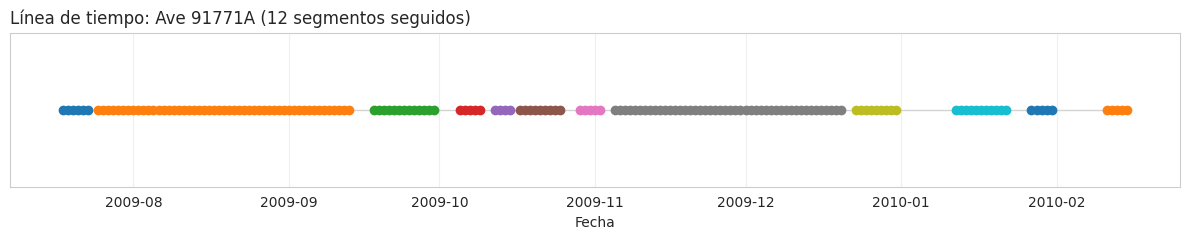

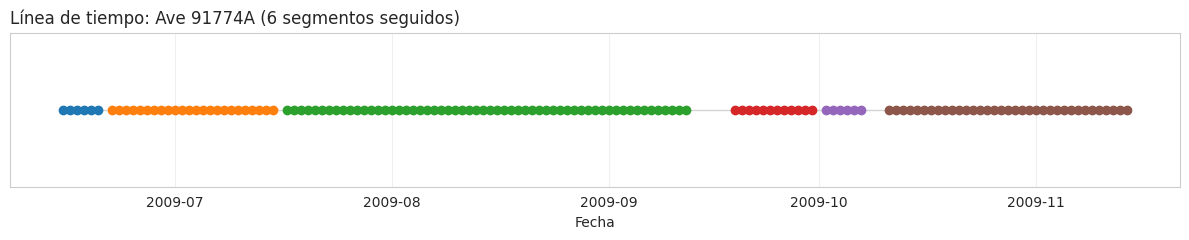

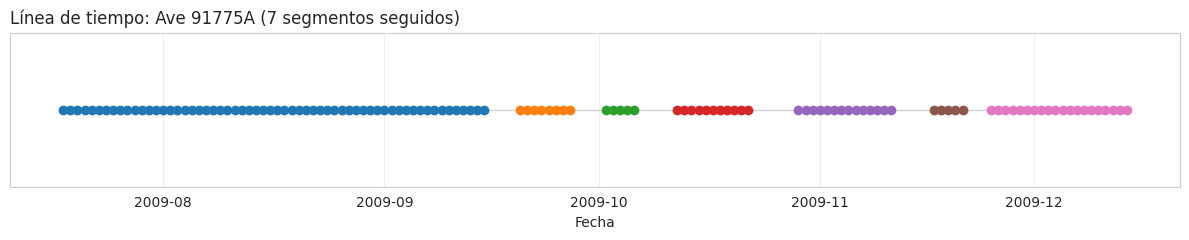

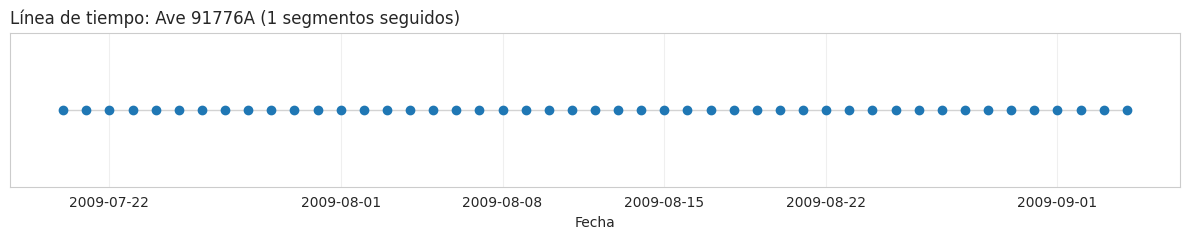

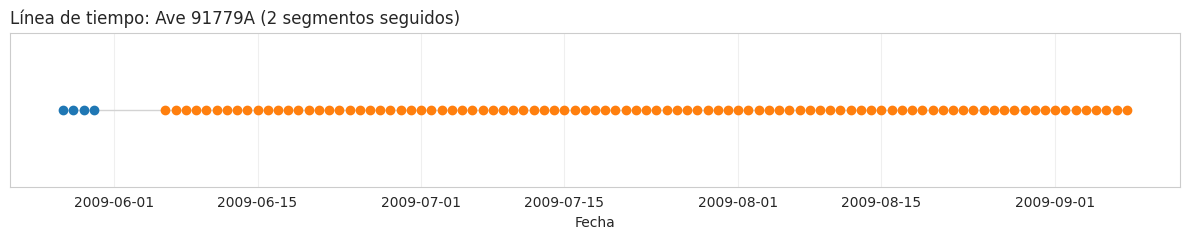

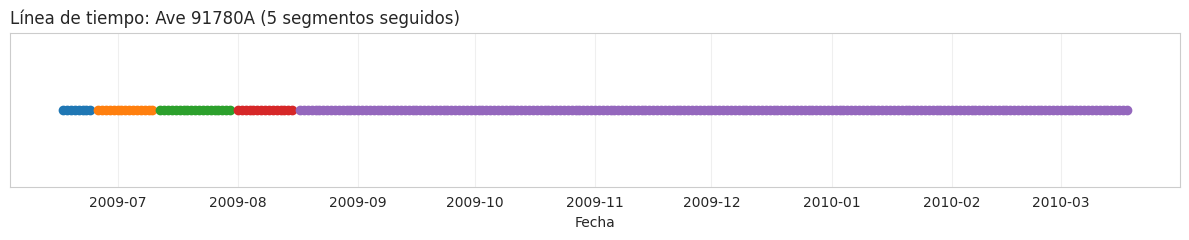

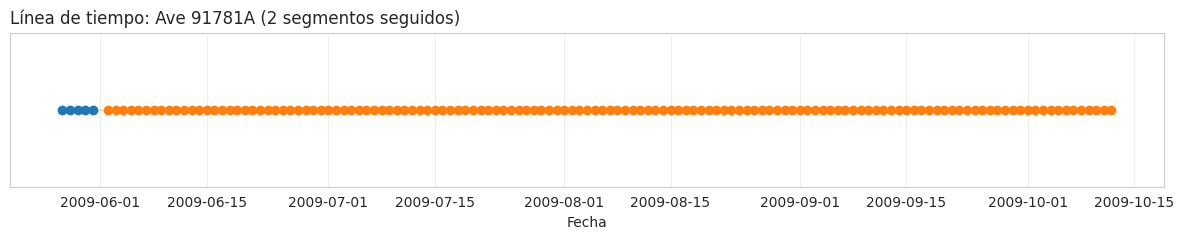

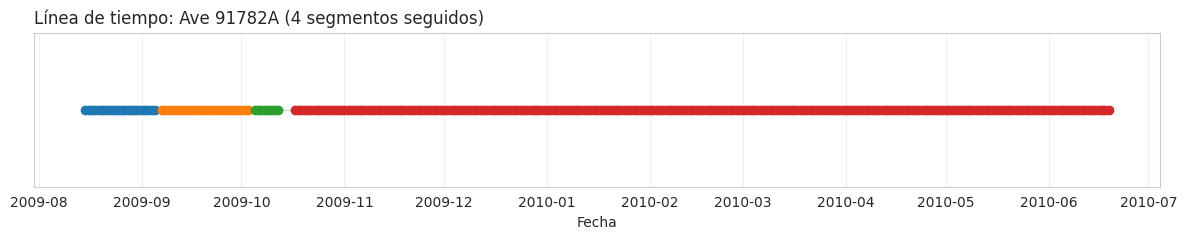

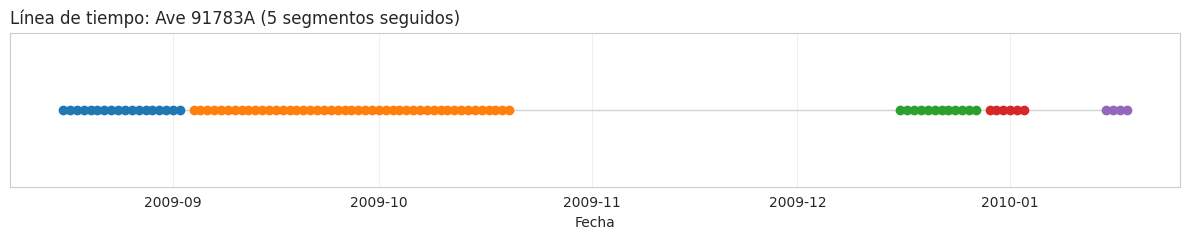

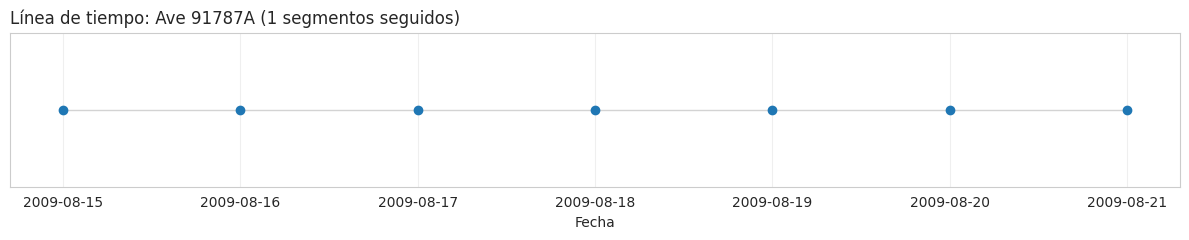

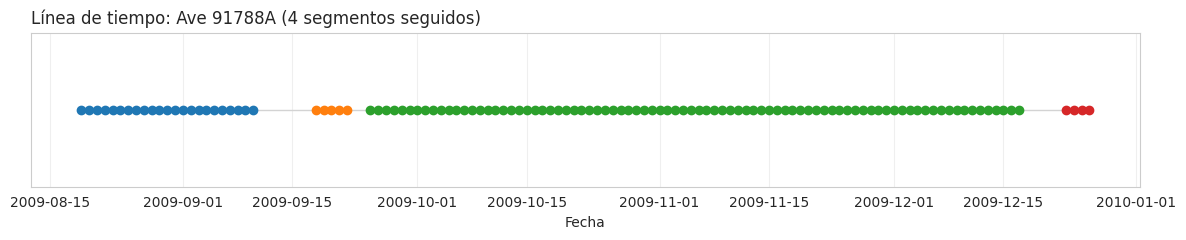

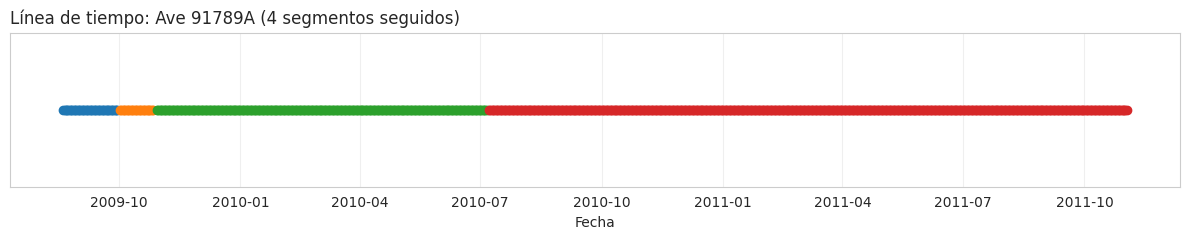

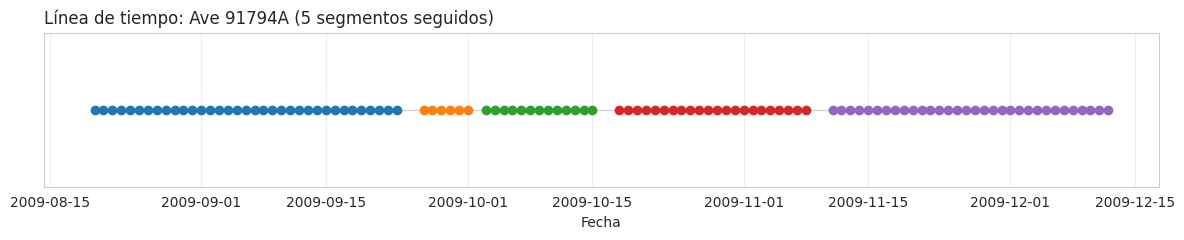

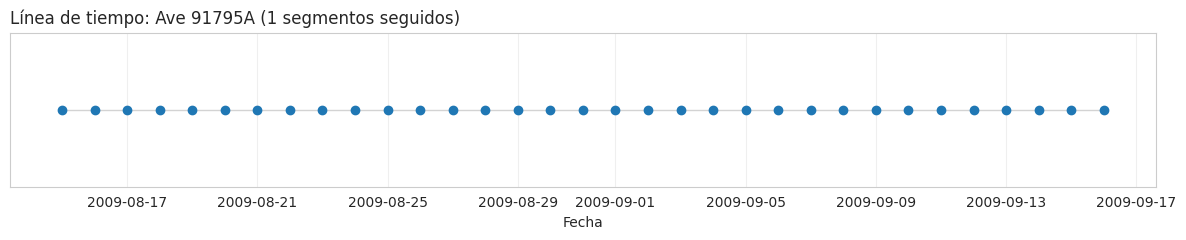

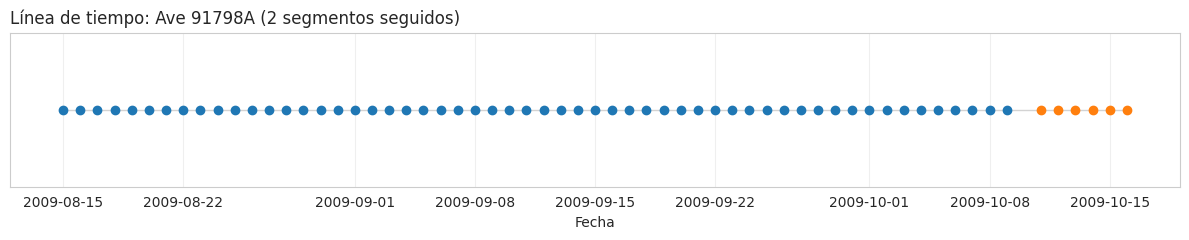

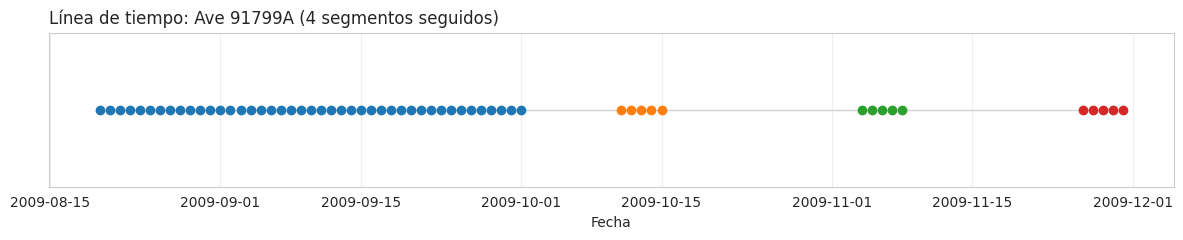

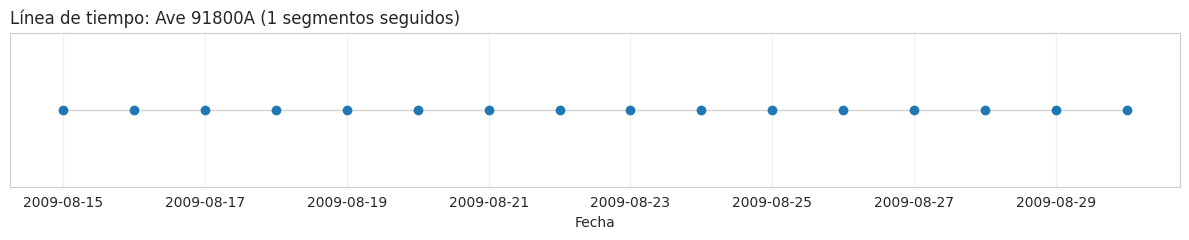

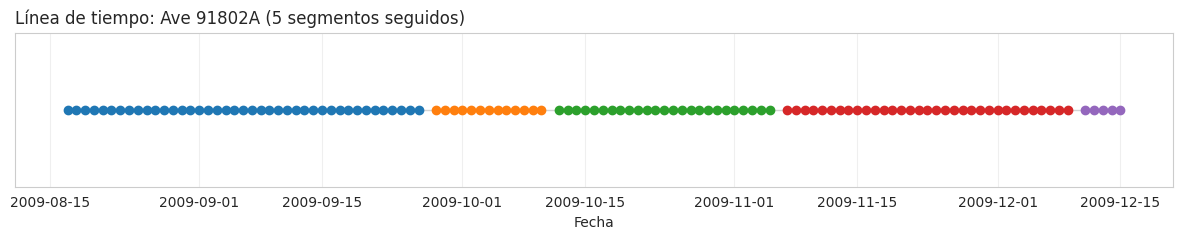

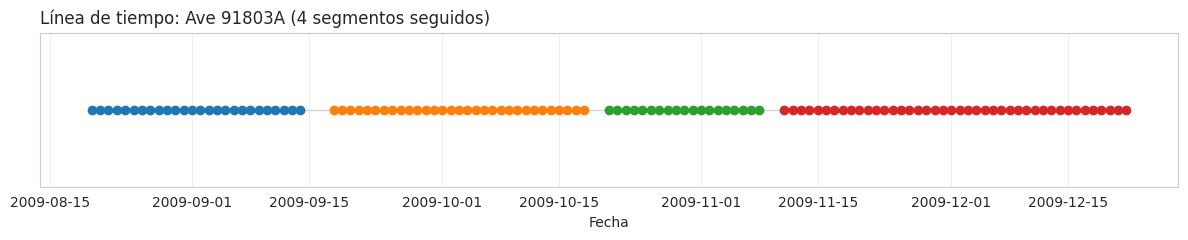

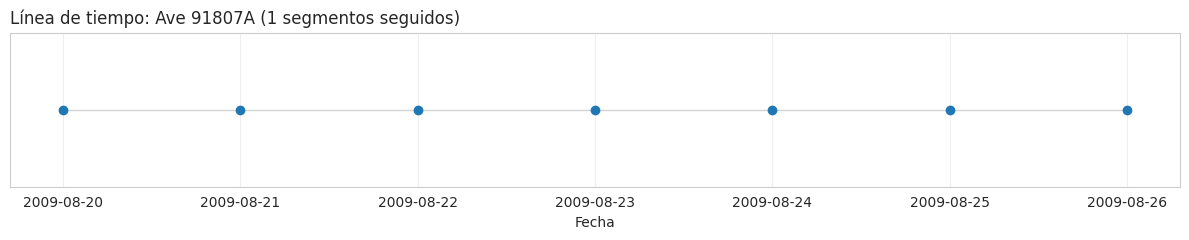

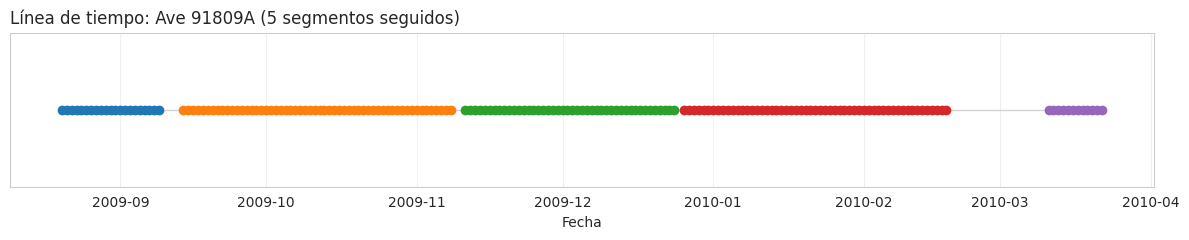

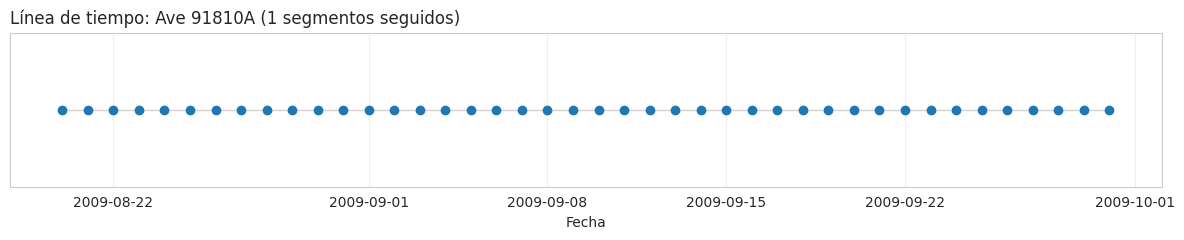

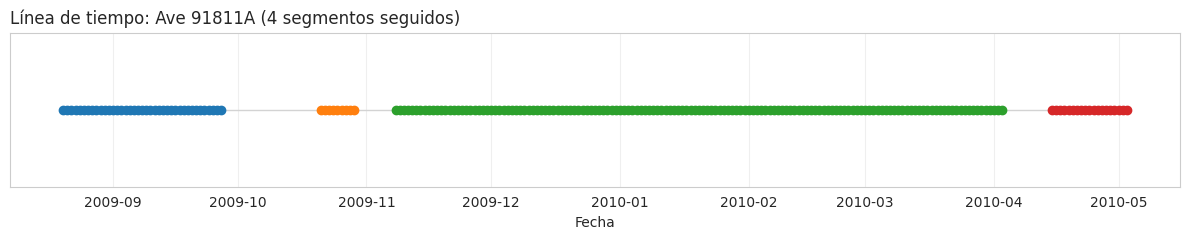

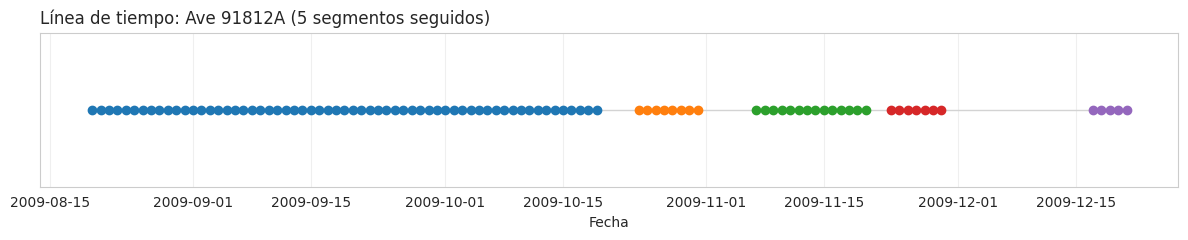

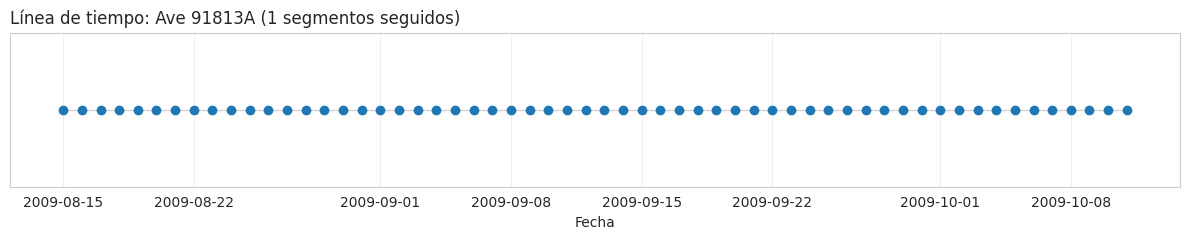

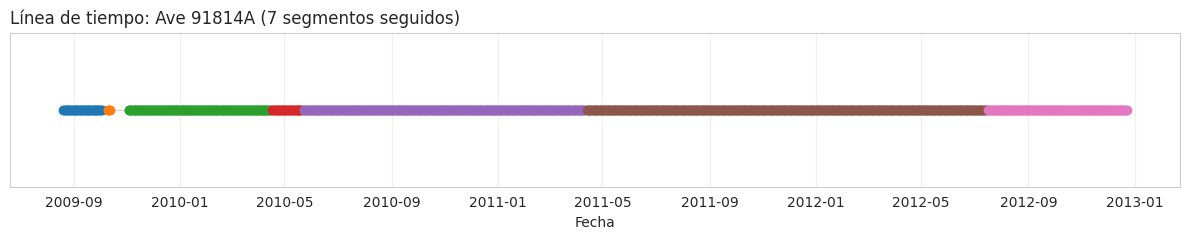

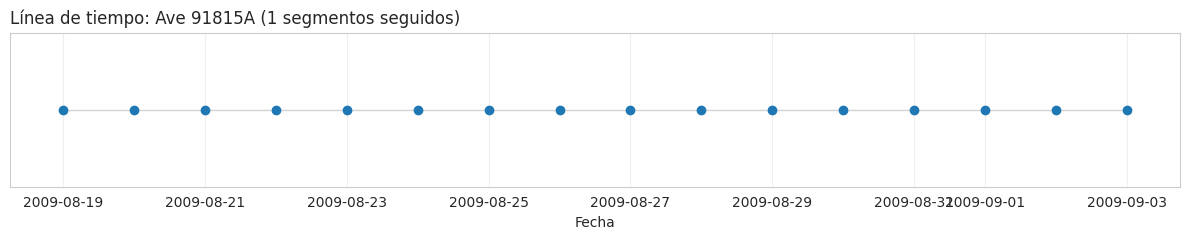

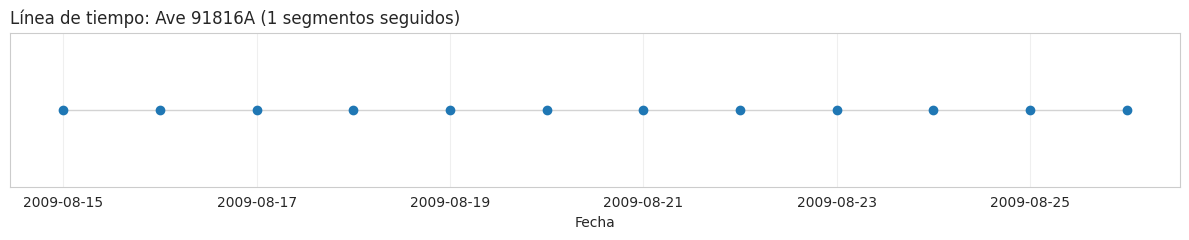

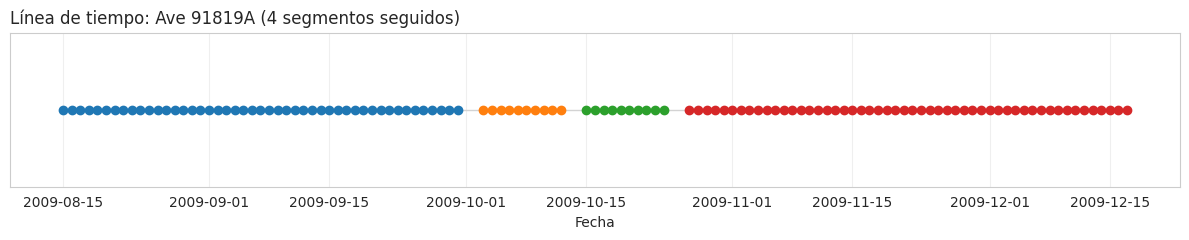

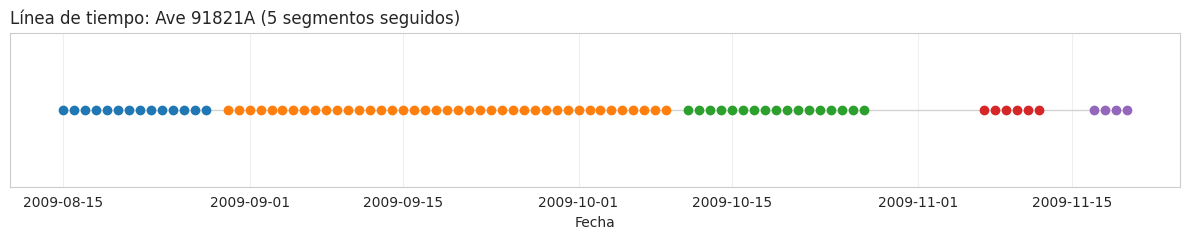

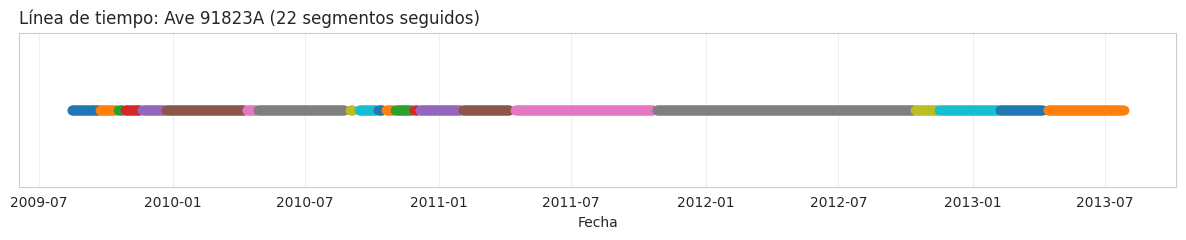

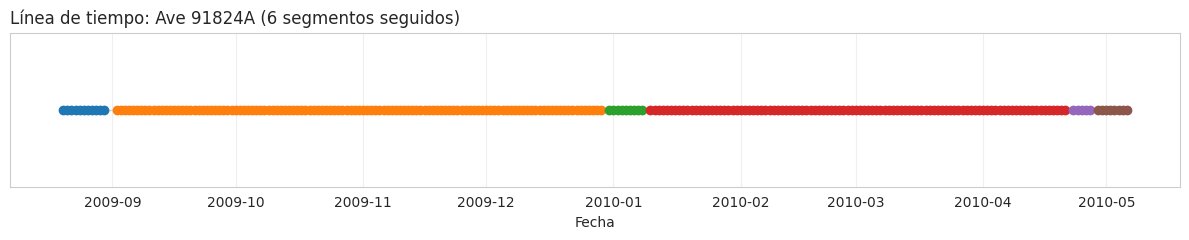

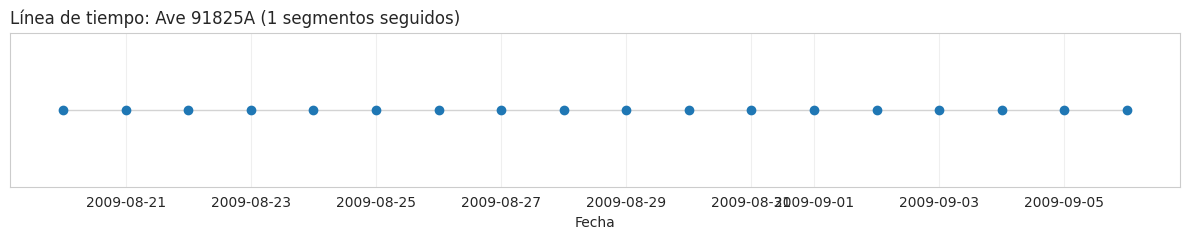

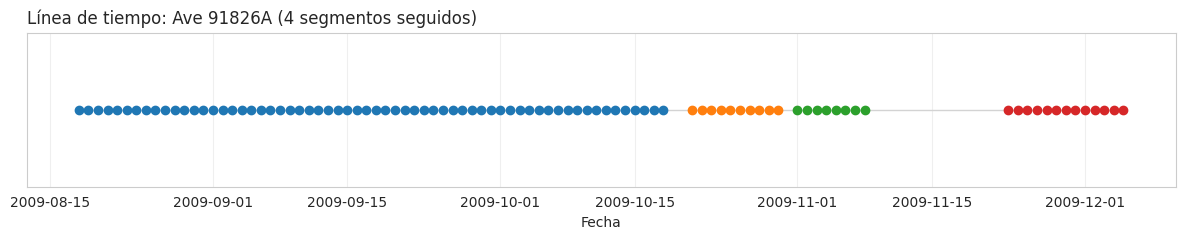

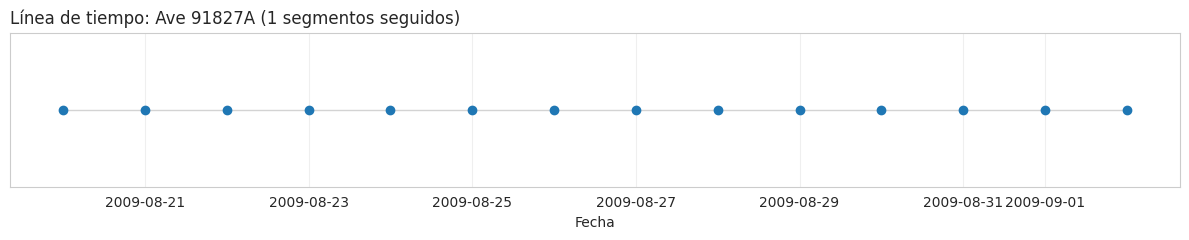

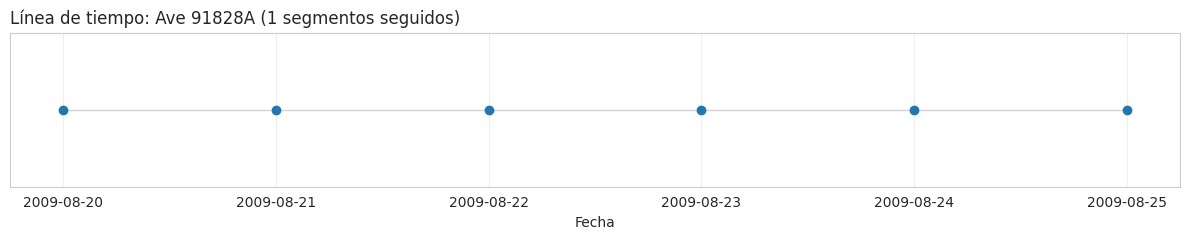

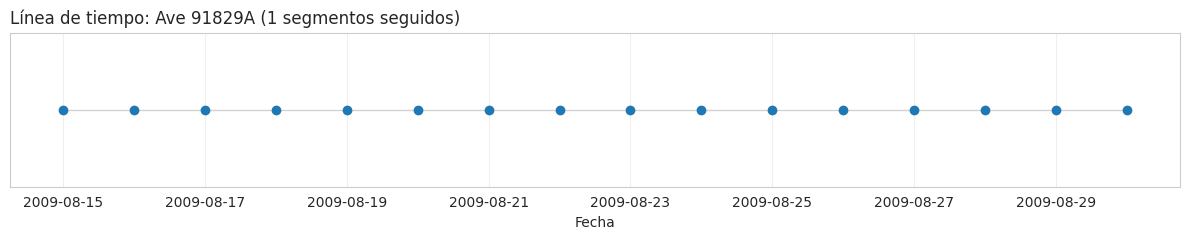

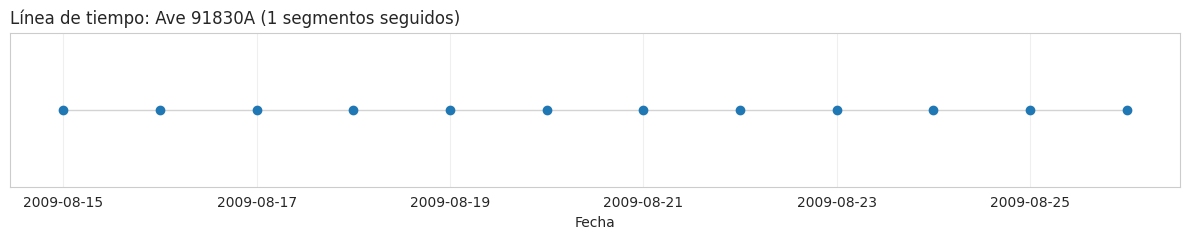

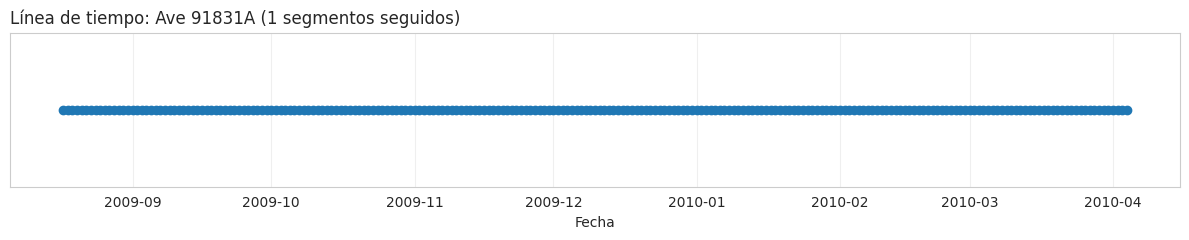

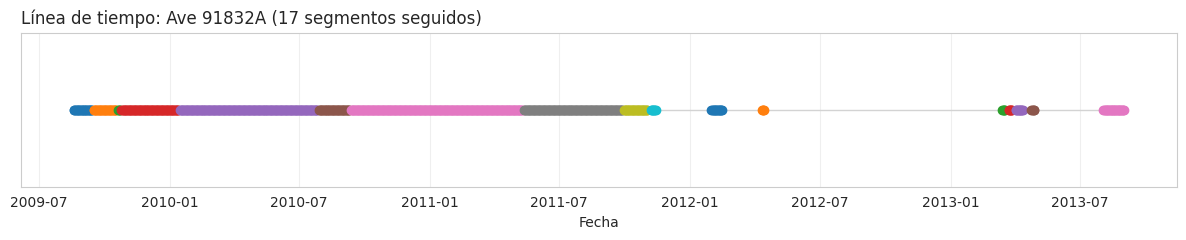

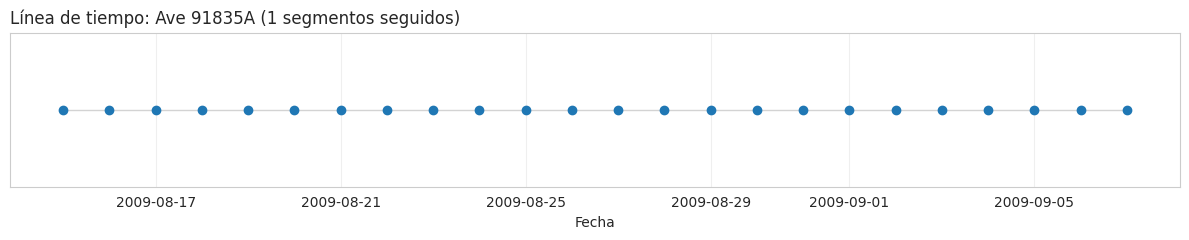

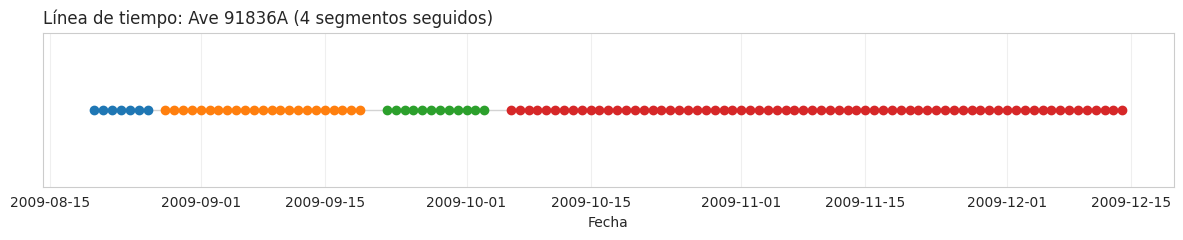

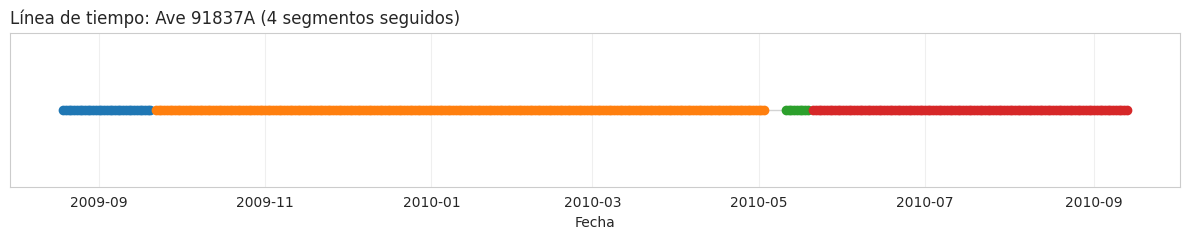

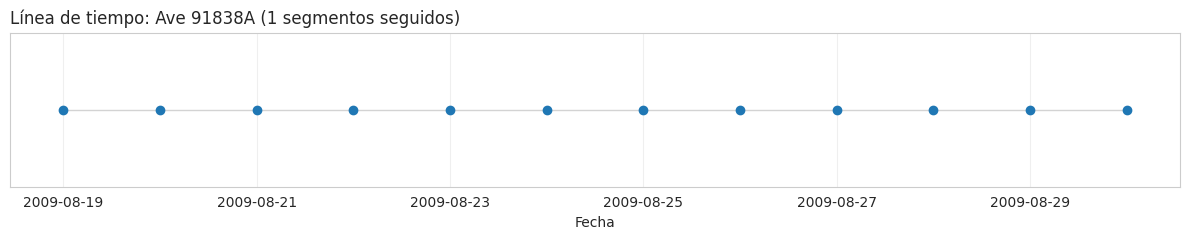

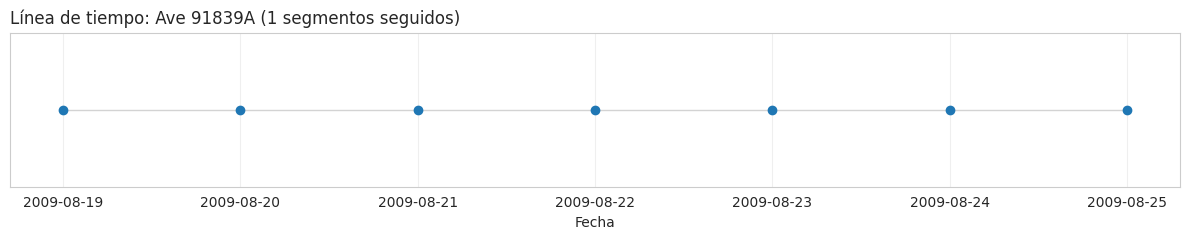

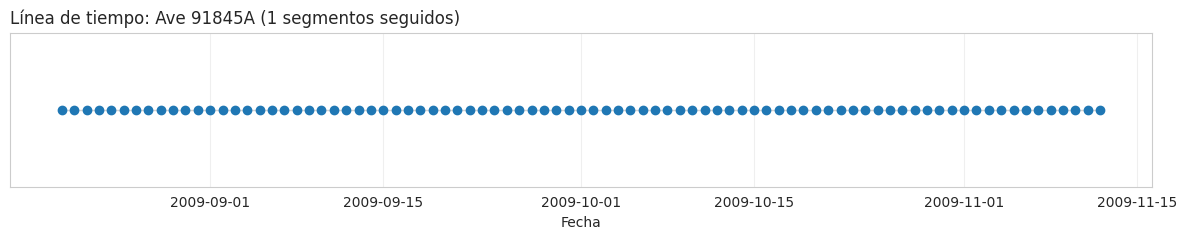

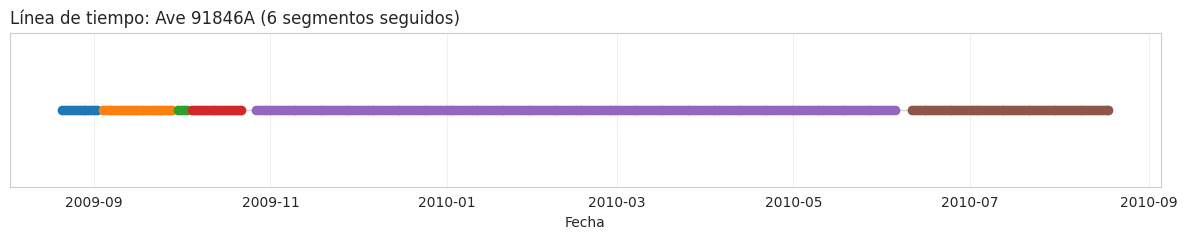

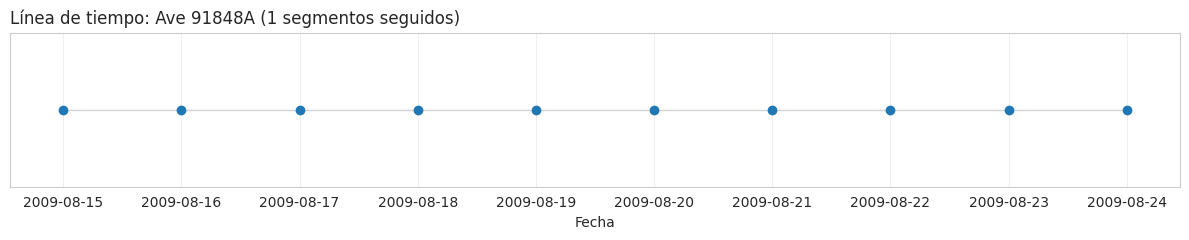

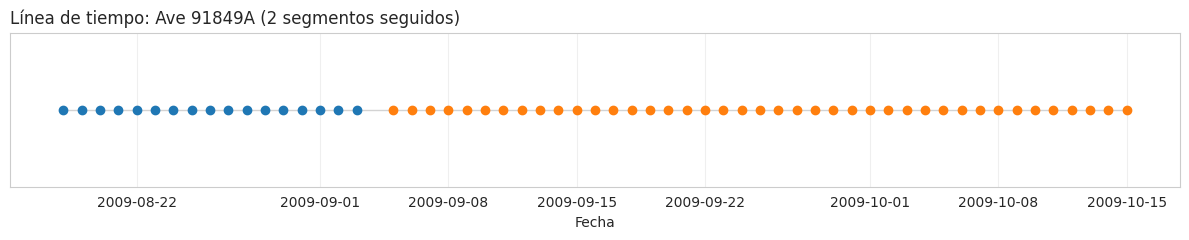

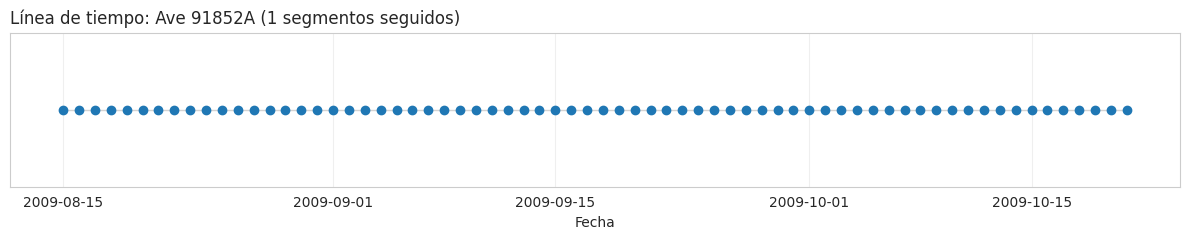

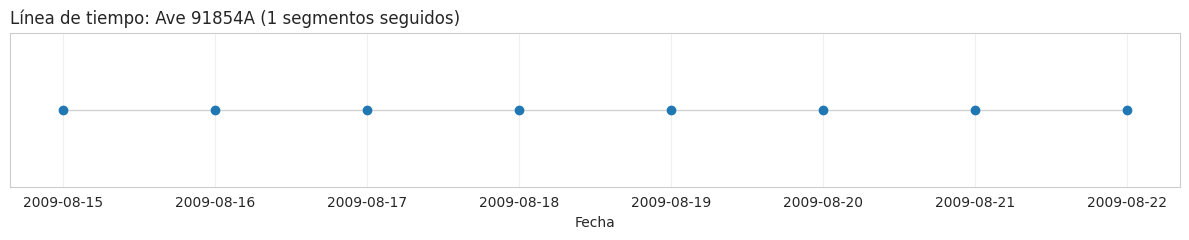

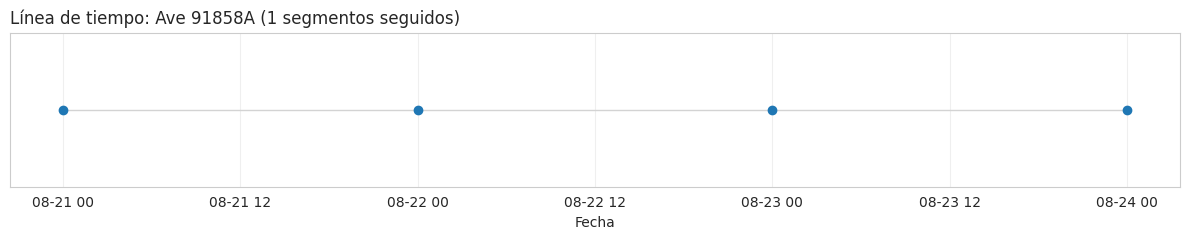

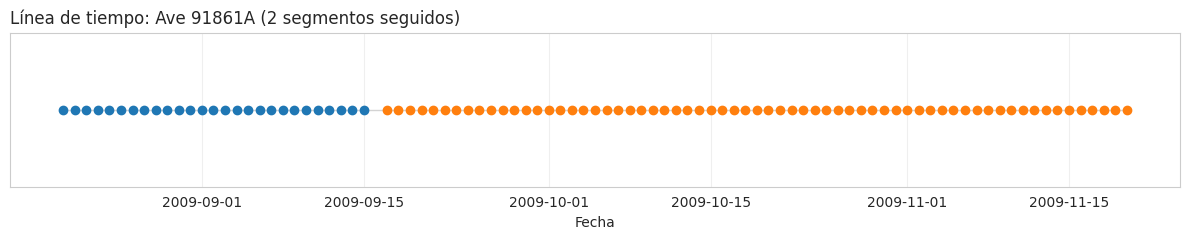

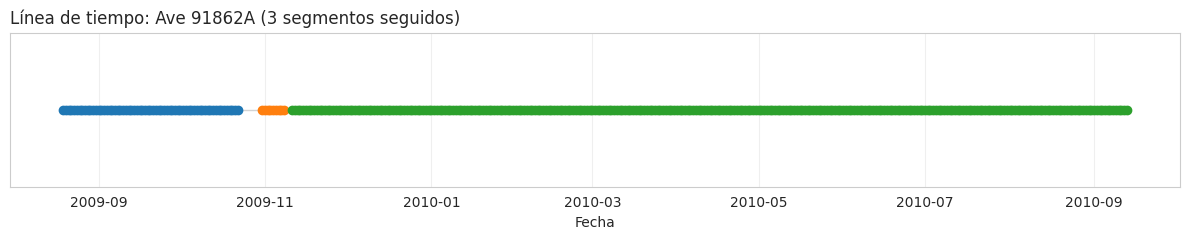

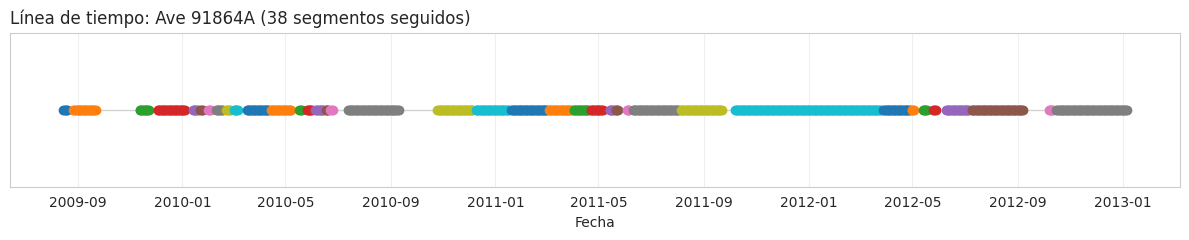

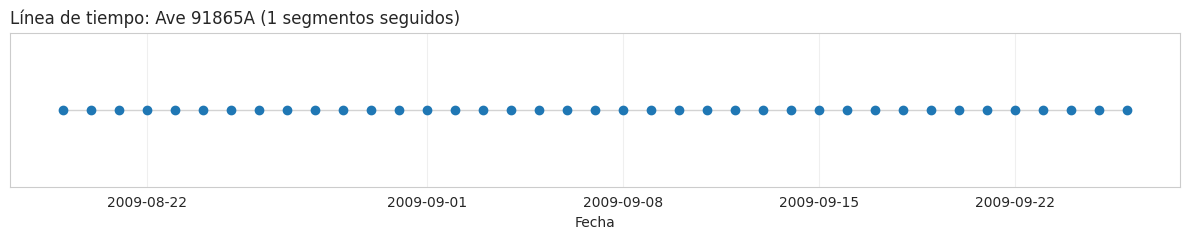

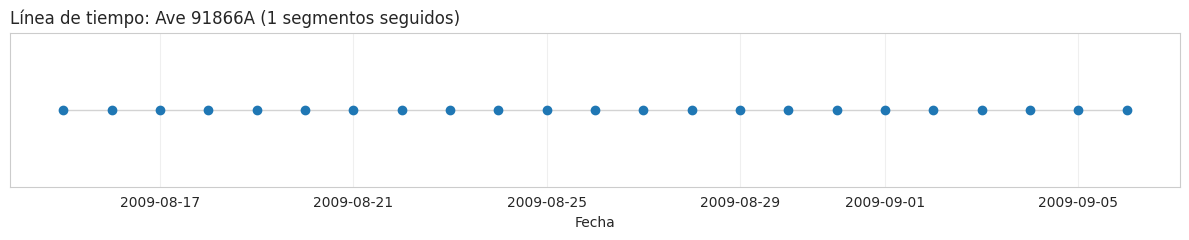

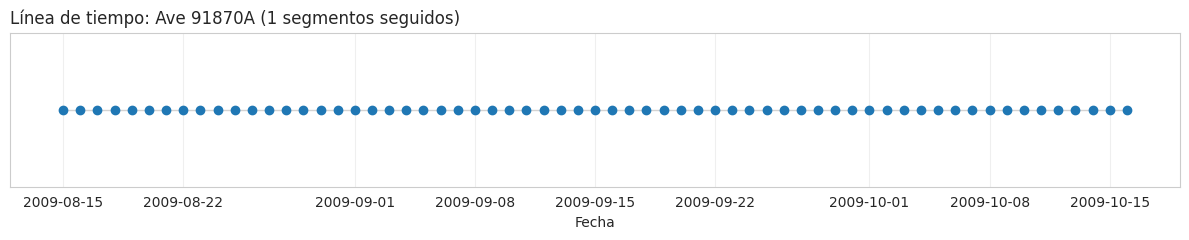

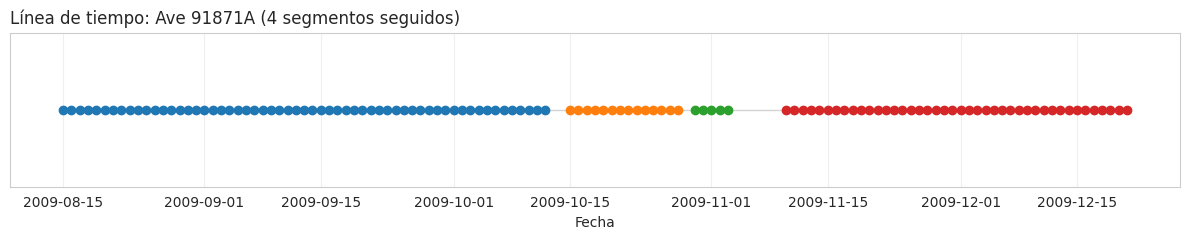

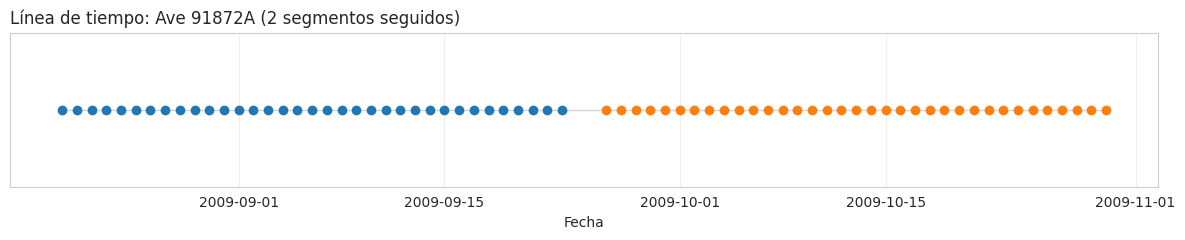

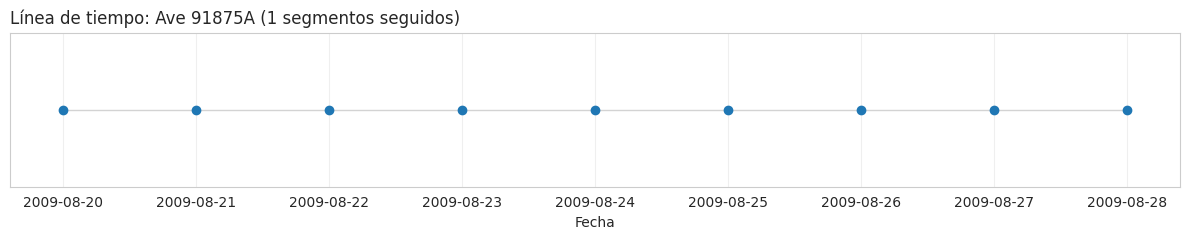

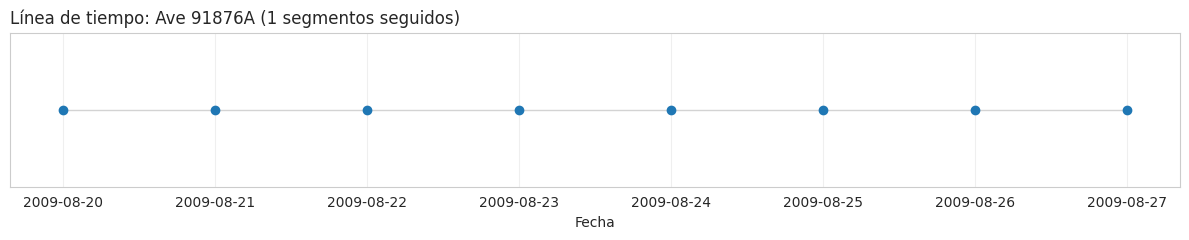

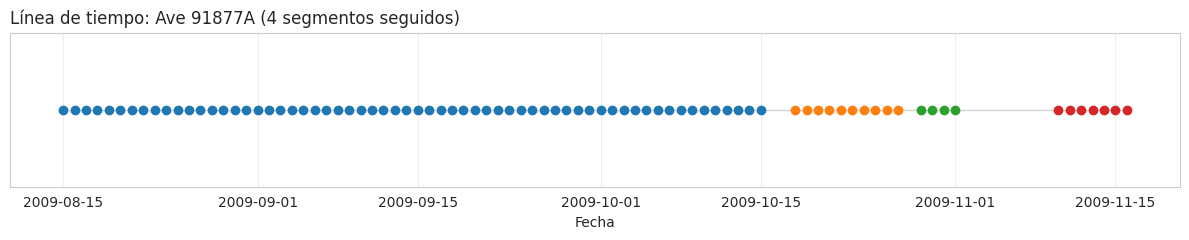

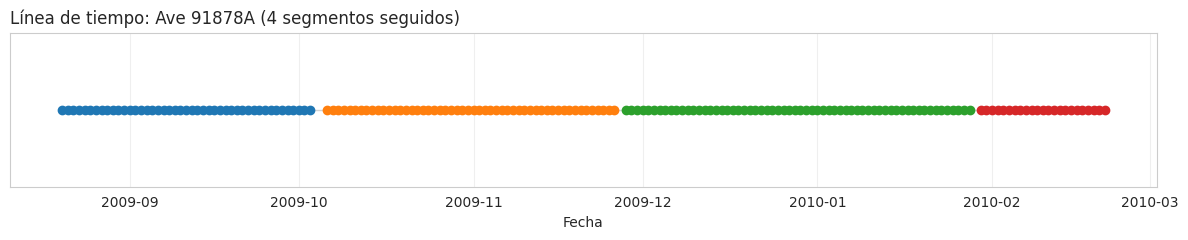

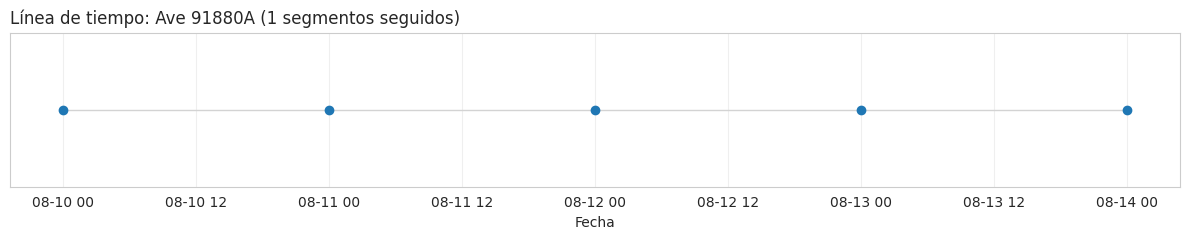

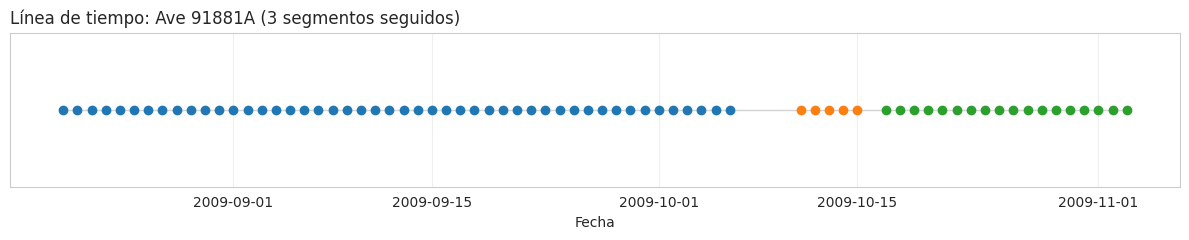

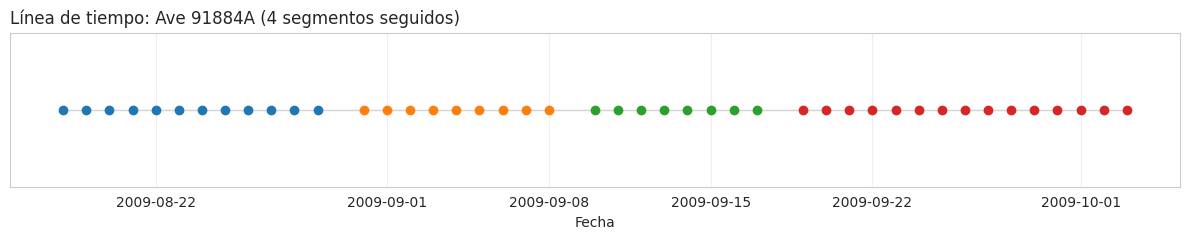

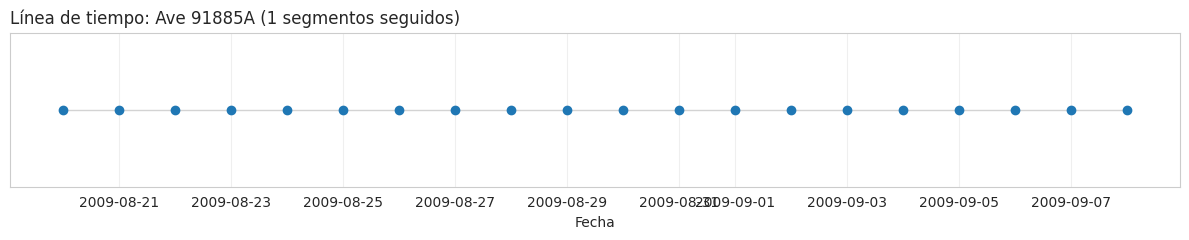

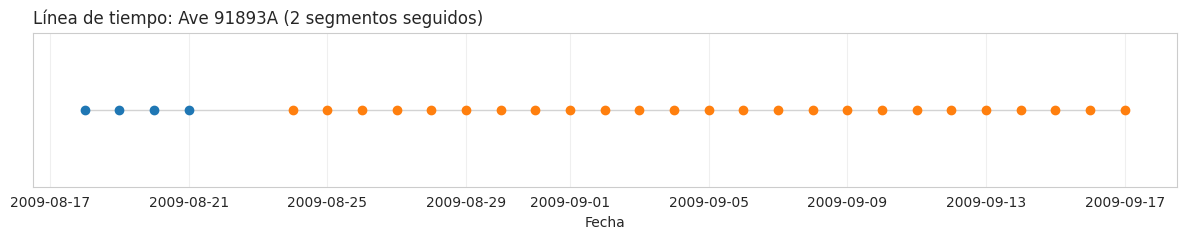

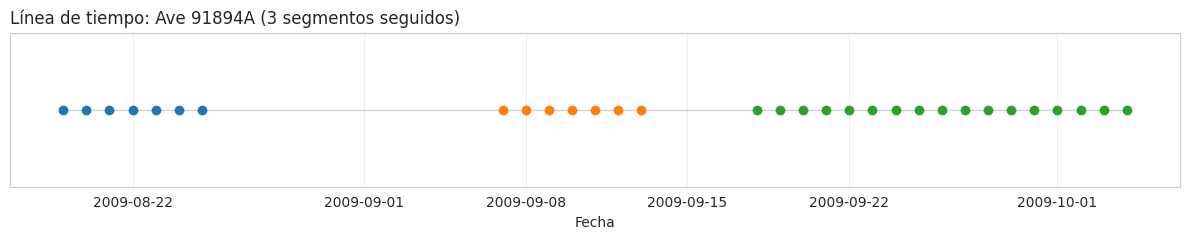

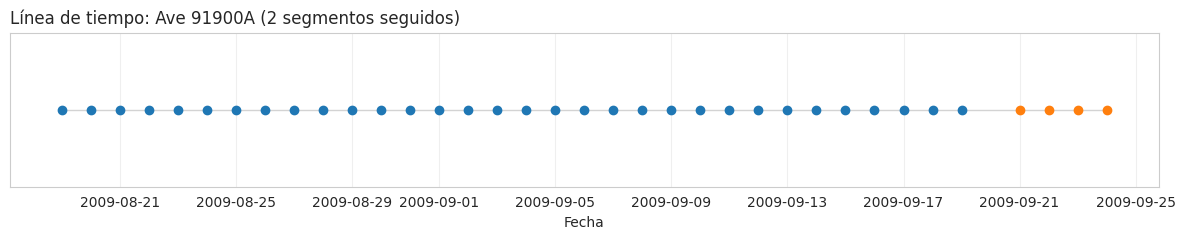

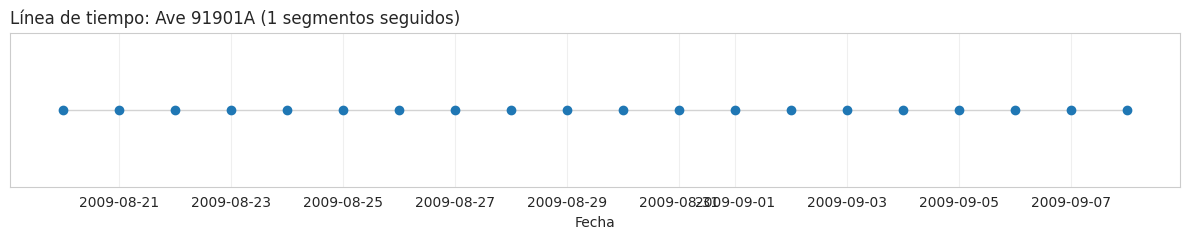

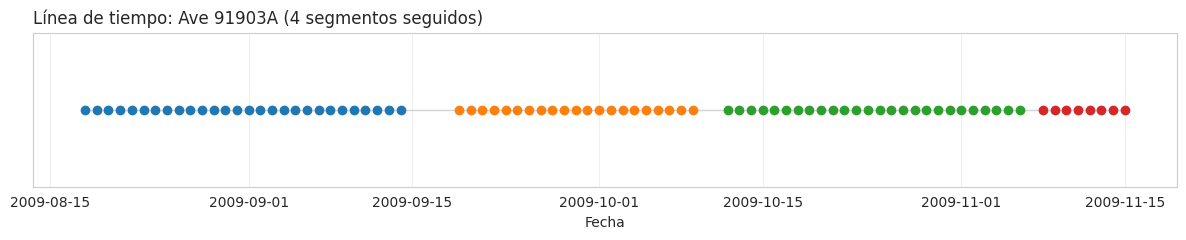

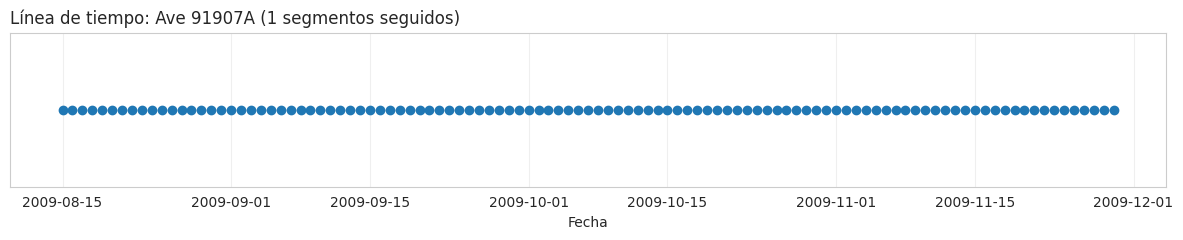

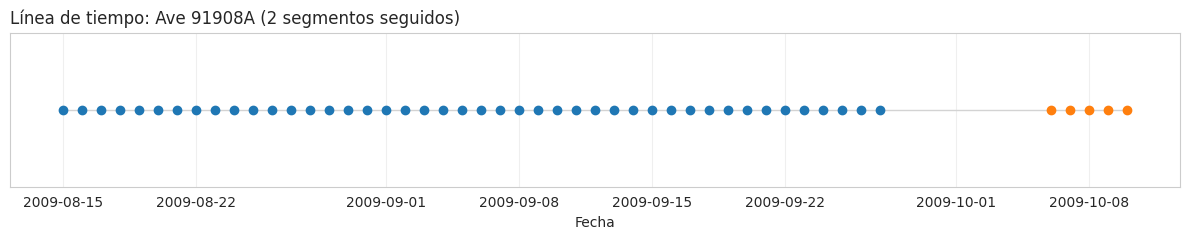

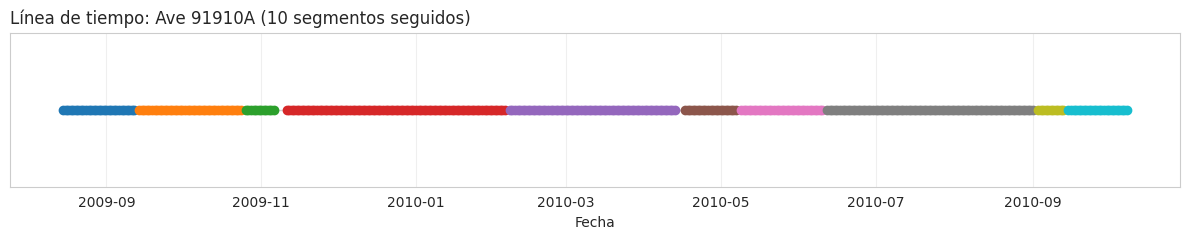

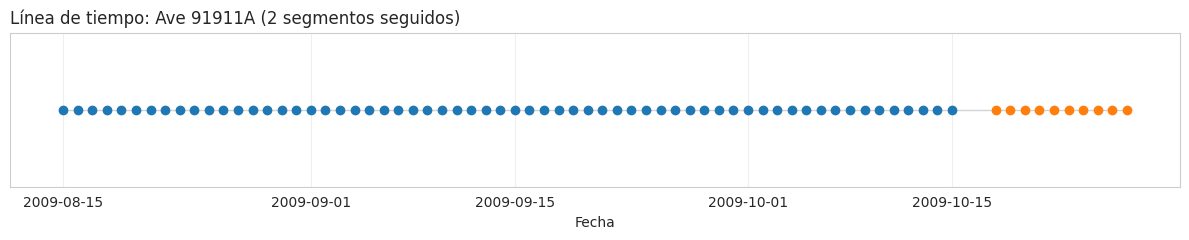

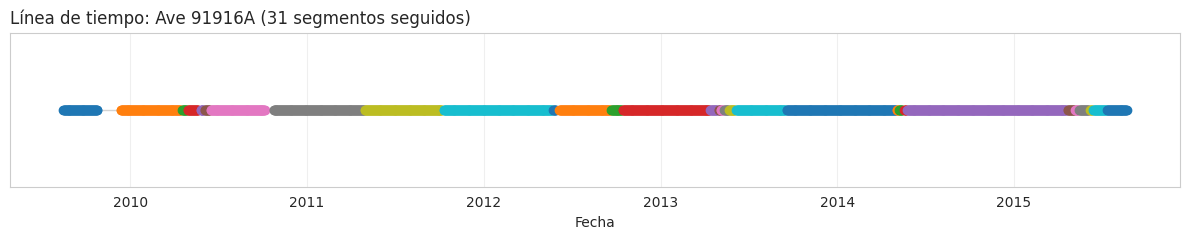

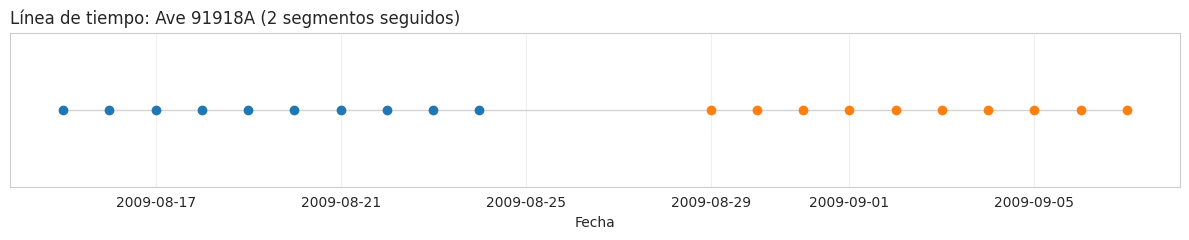

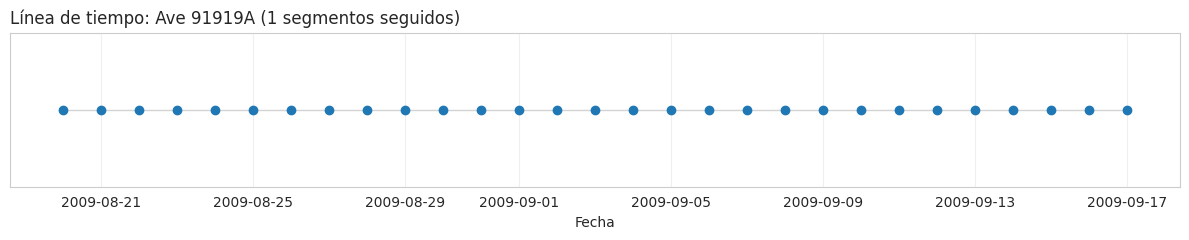

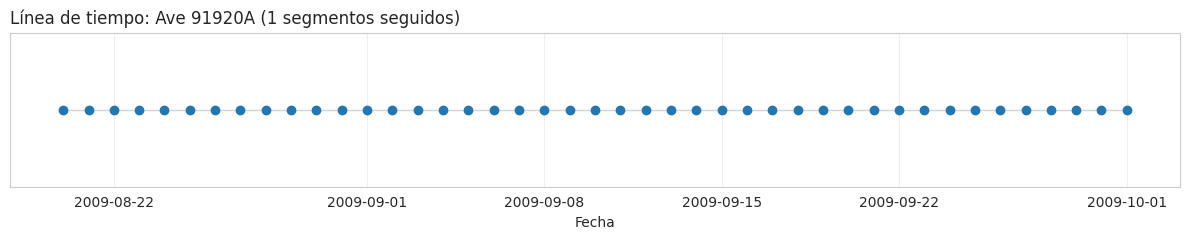

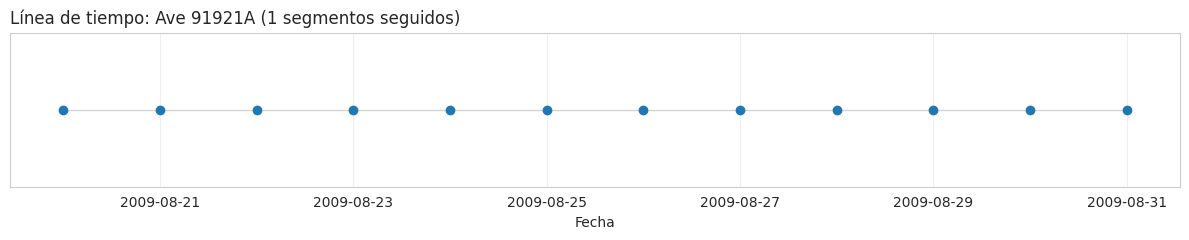

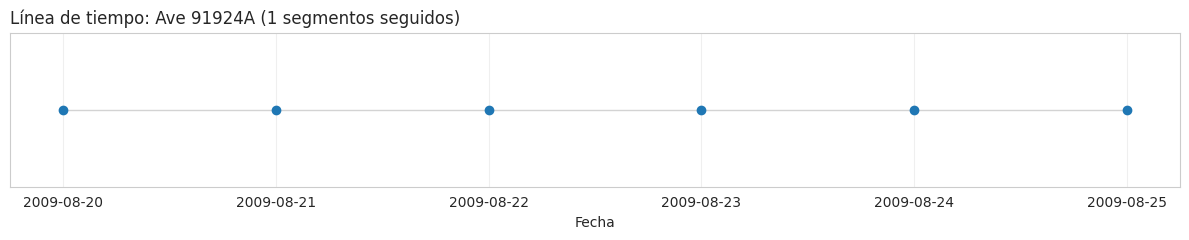

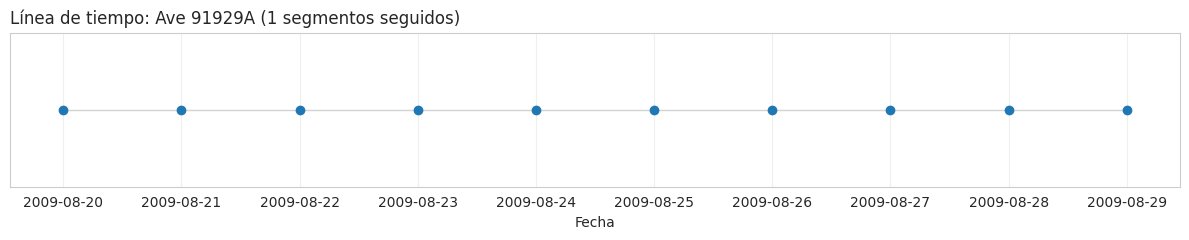

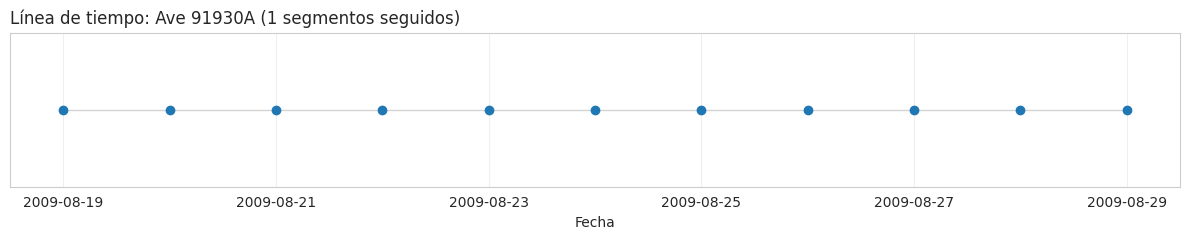

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Aseguramos que trabajamos con el dataframe final y las fechas son correctas
df_final['date'] = pd.to_datetime(df_final['date'])

# --- OPCIÓN A: Todas las aves con segmentos en colores ---
plt.figure(figsize=(14, 8))

# Usamos 'hue' para que cada segmento tenga su propio color
# jitter=False para que los puntos no bailen y se vea la línea clara
sns.stripplot(
    data=df_final, 
    x='date', 
    y='animal_id', 
    hue='trayectoria_id', 
    jitter=False, 
    marker="|", 
    size=15,
    palette='viridis' # Una paleta de colores variada
)

plt.title('Continuidad de Registros por Ave y Segmentos de Días Seguidos', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('ID del Ave', fontsize=12)
plt.xticks(rotation=45)
plt.legend([],[], frameon=False) # Quitamos la leyenda porque habría cientos de segmentos
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- OPCIÓN B: Gráfica individual por ave con colores por segmento ---
unique_animals = df_final['animal_id'].unique()

for animal in unique_animals:
    subset_ave = df_final[df_final['animal_id'] == animal]
    
    plt.figure(figsize=(12, 2.5))
    
    # Línea base gris para ver el periodo total de esa ave
    plt.hlines(y=1, xmin=subset_ave['date'].min(), xmax=subset_ave['date'].max(), 
               colors='lightgray', linewidth=1, zorder=1)
    
    # Dibujamos cada segmento de un color distinto
    # Iteramos por los segmentos únicos de este animal
    segmentos = subset_ave['trayectoria_id'].unique()
    
    for i, seg in enumerate(segmentos):
        subset_seg = subset_ave[subset_ave['trayectoria_id'] == seg]
        plt.plot(
            subset_seg['date'], 
            [1]*len(subset_seg), 
            'o', 
            markersize=6, 
            label=f'Seg {i+1}',
            zorder=2
        )
    
    plt.title(f'Línea de tiempo: Ave {animal} ({len(segmentos)} segmentos seguidos)', loc='left', fontsize=12)
    plt.yticks([]) 
    plt.xlabel('Fecha')
    plt.grid(axis='x', alpha=0.3)
    
    # Si tienes muchos segmentos, la leyenda puede molestar, puedes comentarla:
    # plt.legend(loc='upper right', fontsize='small', ncol=5) 
    
    plt.tight_layout()
    plt.show()